In [1]:
import sys
import os
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
from pathlib import Path
from matplotlib.lines import Line2D

_HERE = Path.cwd()
sys.path.insert(0, str(_HERE))
sys.path.insert(0, str(_HERE / 'cloud_roots'))

from cass_analysis import (
    load_stats, load_stats_ensemble,
    RunSet,
    conditioned_means_ensemble,
    lwp_integral, _to_plottime, cloud_top_za,
    seb_residual,
    plot_seb_timeseries, plot_seb_residual, plot_flux_conditioned,
    sim_time_to_lst, lst_window_mask,
    FLUX_COLORS, RT_STYLE, RT_LABEL,
    rho, cp, Lv, LST_OFFSET,
)
from catalog import make_runset, CASS_ROOT

In [2]:
# ── experiment ────────────────────────────────────────────────────────────────
V2_EXPT        = 'no_aerosols_zero_wind_v2'
EXPT_KEY       = V2_EXPT          # notebook-wide v2 migration
N_REPS         = 4
rs             = make_runset(EXPT_KEY, n_reps=N_REPS)
print(rs)

# ── cloud-root profile / composite config ─────────────────────────────────────
COMPOSITE_ROOT = str(CASS_ROOT / 'analysis' / 'cloud_root_composite')
LST_MIN        = 10.5
LST_MAX        = 17.5
ORIENT         = 'xz'
SAVE_PDF       = False

# ── CASES for cloud-root profiles / composites ────────────────────────────────
CASES = [
    dict(key='1D', rt='2stream',   comp_expt=EXPT_KEY, comp_rt='2stream'),
    dict(key='3D', rt='raytracer', comp_expt=EXPT_KEY, comp_rt='raytracer'),
]


RunSet('No aerosols, zero wind', root=/pscratch/sd/m/mpowell/CASS_LES/experiments/no_aerosols_zero_wind_v2)
  2stream: 4 rep(s)
  raytracer: 4 rep(s)


In [3]:
# ── LWP loading ───────────────────────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    dirs_2s = rs.dirs.get('2stream', [])
    dirs_rt = rs.dirs.get('raytracer', [])

reps_2s  = [load_stats(d) for d in dirs_2s]
reps_rt  = [load_stats(d) for d in dirs_rt]
n_paired = min(len(reps_2s), len(reps_rt))
nt       = min(*(s['qlqi_path'].sizes['time'] for s in reps_2s + reps_rt))

lwp_1d_reps = np.stack([s['qlqi_path'].values[:nt] * 1e3 for s in reps_2s[:n_paired]])
lwp_3d_reps = np.stack([s['qlqi_path'].values[:nt] * 1e3 for s in reps_rt[:n_paired]])
diff_reps   = lwp_3d_reps - lwp_1d_reps

lwp_1d     = lwp_1d_reps.mean(axis=0)
lwp_3d     = lwp_3d_reps.mean(axis=0)
lwp_1d_std = lwp_1d_reps.std(axis=0, ddof=0)
lwp_3d_std = lwp_3d_reps.std(axis=0, ddof=0)
diff       = diff_reps.mean(axis=0)
diff_std   = diff_reps.std(axis=0, ddof=0)

t_local = reps_2s[0]['t_local'].values[:nt]
t_sec   = reps_2s[0]['t_sec'].values[:nt]
dt_s    = float(t_sec[1] - t_sec[0]) if len(t_sec) > 1 else 60.0

cloudy_mask  = (lwp_1d > 0.1) | (lwp_3d > 0.1)
int_diff     = lwp_integral(diff, dt_s, cloudy_mask=cloudy_mask)
int_1d       = lwp_integral(lwp_1d, dt_s, cloudy_mask=cloudy_mask)
norm_int     = int_diff / int_1d * 100 if abs(int_1d) > 1e-6 else np.nan
norm_int_std = float(np.std(
    [lwp_integral(diff_reps[r], dt_s, cloudy_mask=cloudy_mask) / int_1d * 100
     for r in range(n_paired)], ddof=0)) if abs(int_1d) > 1e-6 else np.nan


# ── Cloud cover (domain fraction of columns with ql>0) ──────────────────────
cc_1d_reps = np.stack([s['ql_cover'].values[:nt] for s in reps_2s[:n_paired]])
cc_3d_reps = np.stack([s['ql_cover'].values[:nt] for s in reps_rt[:n_paired]])
cc_1d, cc_1d_std = cc_1d_reps.mean(0), cc_1d_reps.std(0, ddof=0)
cc_3d, cc_3d_std = cc_3d_reps.mean(0), cc_3d_reps.std(0, ddof=0)

# ── Cloud-layer top height from ql_frac profiles (cass_analysis.cloud_top_za) ─
z_grid = reps_2s[0]['z'].values
def _cloud_top_ts(s):
    qlf = s['ql_frac'].values[:nt]   # (nt, nz)
    return np.array([cloud_top_za(z_grid, qlf[t]) for t in range(nt)])
ct_1d_reps = np.stack([_cloud_top_ts(s) for s in reps_2s[:n_paired]])
ct_3d_reps = np.stack([_cloud_top_ts(s) for s in reps_rt[:n_paired]])
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    ct_1d = np.nanmean(ct_1d_reps, axis=0); ct_1d_std = np.nanstd(ct_1d_reps, axis=0, ddof=0)
    ct_3d = np.nanmean(ct_3d_reps, axis=0); ct_3d_std = np.nanstd(ct_3d_reps, axis=0, ddof=0)


# ── Cloud size + count (connected components of qlqi_path > 0) ─────────────
from scipy import ndimage
MIN_L_CS = 100.0   # m — drop 1–2 pixel fragments (dx=50 m → single-pixel L≈56 m)

def _rep_cloud_size_series(run_dir):
    ds = xr.open_dataset(Path(run_dir) / 'qlqi_path.xy.nc', decode_times=False)
    qlp = ds['qlqi_path'].values
    if qlp.ndim == 4 and qlp.shape[1] == 1:
        qlp = qlp[:, 0]
    dx = float(ds['x'].values[1] - ds['x'].values[0])
    dy = float(ds['y'].values[1] - ds['y'].values[0])
    t_sec_cs = ds['time'].values
    ds.close()
    n_t = qlp.shape[0]
    mL = np.full(n_t, np.nan); nO = np.zeros(n_t, int)
    for k in range(n_t):
        mask = qlp[k] > 0
        if not mask.any():
            continue
        lbl, n = ndimage.label(mask)
        if n == 0:
            continue
        areas = ndimage.sum(mask, lbl, index=np.arange(1, n + 1)) * dx * dy
        Ls    = 2.0 * np.sqrt(areas / np.pi)
        keep  = Ls >= MIN_L_CS
        if keep.any():
            mL[k] = float(Ls[keep].mean())
            nO[k] = int(keep.sum())
    return t_sec_cs, mL, nO

_cs_2s = [_rep_cloud_size_series(d) for d in dirs_2s[:n_paired]]
_cs_rt = [_rep_cloud_size_series(d) for d in dirs_rt[:n_paired]]
nt_cs  = min(len(s[0]) for s in _cs_2s + _cs_rt)
t_sec_cs = _cs_2s[0][0][:nt_cs]

mL_1d_reps = np.stack([s[1][:nt_cs] for s in _cs_2s])
mL_3d_reps = np.stack([s[1][:nt_cs] for s in _cs_rt])
nc_1d_reps = np.stack([s[2][:nt_cs] for s in _cs_2s]).astype(float)
nc_3d_reps = np.stack([s[2][:nt_cs] for s in _cs_rt]).astype(float)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    mL_1d, mL_1d_std = np.nanmean(mL_1d_reps, 0), np.nanstd(mL_1d_reps, 0, ddof=0)
    mL_3d, mL_3d_std = np.nanmean(mL_3d_reps, 0), np.nanstd(mL_3d_reps, 0, ddof=0)
    nc_1d, nc_1d_std = np.nanmean(nc_1d_reps, 0), np.nanstd(nc_1d_reps, 0, ddof=0)
    nc_3d, nc_3d_std = np.nanmean(nc_3d_reps, 0), np.nanstd(nc_3d_reps, 0, ddof=0)

print(f'LWP loaded:  n_paired={n_paired},  nt={nt}')
print(f'Normalised integral: {norm_int:+.2f} \u00b1 {norm_int_std:.2f} %')

LWP loaded:  n_paired=4,  nt=167
Normalised integral: +45.74 ± 3.47 %


Text(0.5, 0.98, 'Local solar time 14:30   (clear-sky $=$ 806 W m$^{-2}$)')

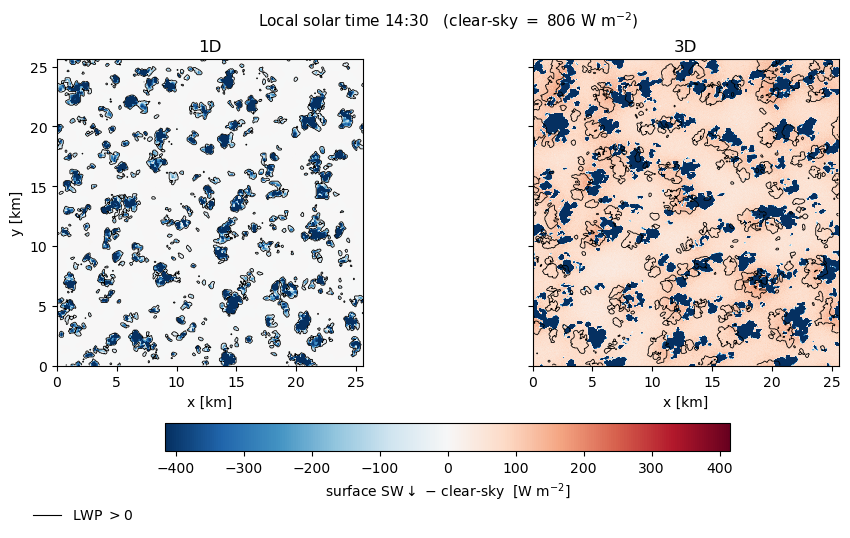

In [17]:
# ── Surface SW anomaly vs clear-sky, 1D & 3D, one rep, one snapshot ──────────
import matplotlib.patheffects as pe

REP      = 1         # rep index into dirs_2s / dirs_rt
LST_WANT = 14.5       # local solar time of the snapshot (h)
LWP_THR  = 1e-5       # kg m^-2; qlqi_path > this  -> "cloudy" column

d1 = Path(dirs_2s[REP])   # 1D (2stream)
d3 = Path(dirs_rt[REP])   # 3D (raytracer)

def _xy(run_dir, fname, var):
    ds = xr.open_dataset(run_dir / fname, decode_times=False)
    da = ds[var].squeeze()
    return da, ds['time'].values, ds['x'].values, ds['y'].values

# 1D total surface SW down; 3D = direct + diffuse ray-tracer
sw1d_t, t1, x, y       = _xy(d1, 'sw_flux_dn.xy.nc', 'sw_flux_dn')
dir3_t, t3, _, _       = _xy(d3, 'sw_flux_sfc_dir_rt.xy.nc', 'sw_flux_sfc_dir_rt')
dif3_t, _,  _, _       = _xy(d3, 'sw_flux_sfc_dif_rt.xy.nc', 'sw_flux_sfc_dif_rt')
sw3d_t                 = dir3_t + dif3_t
# LWP (use the 3D run's cloud field for the outline; swap to d1 if you prefer)
lwp1_t, tl1, _, _      = _xy(d1, 'qlqi_path.xy.nc', 'qlqi_path')
lwp3_t, tl3, _, _      = _xy(d3, 'qlqi_path.xy.nc', 'qlqi_path')

# nearest time index in each file to the requested LST
def _idx(t_sec): return int(np.abs(sim_time_to_lst(t_sec) - LST_WANT).argmin())
i1, i3, il1, il3 = _idx(t1), _idx(t3), _idx(tl1), _idx(tl3)
lst_actual = float(sim_time_to_lst(t3)[i3])

sw1d, sw3d = sw1d_t.values[i1], sw3d_t.values[i3]
lwp1, lwp3 = lwp1_t.values[il1], lwp3_t.values[il3]

# clear-sky reference = mean of cloud-free 1D columns (aerosol-free -> clear sky)
clr_mask = lwp1 <= LWP_THR
sw_clr   = float(sw1d[clr_mask].mean()) if clr_mask.sum() > 50 \
           else float(np.percentile(sw1d, 99))

a1, a3 = sw1d - sw_clr, sw3d - sw_clr          # anomalies (W m^-2)
dmax   = float(np.nanpercentile(np.abs(np.concatenate([a1.ravel(), a3.ravel()])), 90))

fig, axs = plt.subplots(1, 2, figsize=(9.5, 5), constrained_layout=True)
panels = [(a1, lwp1, '1D'),
          (a3, lwp3, '3D')]
for ax, (anom, lwp, title) in zip(axs, panels):
    im = ax.pcolormesh(x/1e3, y/1e3, anom, cmap='RdBu_r',
                       vmin=-dmax, vmax=dmax, rasterized=True)
    cs = ax.contour(x/1e3, y/1e3, lwp, levels=[LWP_THR], colors='black', linewidths=0.6)
    ax.set(aspect='equal', xlabel='x [km]', title=title)
    ax.set_ylabel('y [km]' if ax is axs[0] else '')
    if ax is not axs[0]: ax.set_yticklabels([])

cb = fig.colorbar(im, ax=axs, location='bottom', shrink=0.6, pad=0.04,
                  label=r'surface SW$\downarrow$ $-$ clear-sky  [W m$^{-2}$]')
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0],[0], color='black', lw=0.8, label='LWP $> 0$')],
           loc='lower left', frameon=False, bbox_to_anchor=(0.05, -0.06))
h = int(lst_actual); m = int(round((lst_actual - h) * 60))
if m == 60: h, m = h + 1, 0          # guard rounding 59.6 -> 60
fig.suptitle(fr'Local solar time {h:02d}:{m:02d}   '
             fr'(clear-sky $=$ {sw_clr:.0f} W m$^{{-2}}$)', fontsize=11)


## 1. LWP


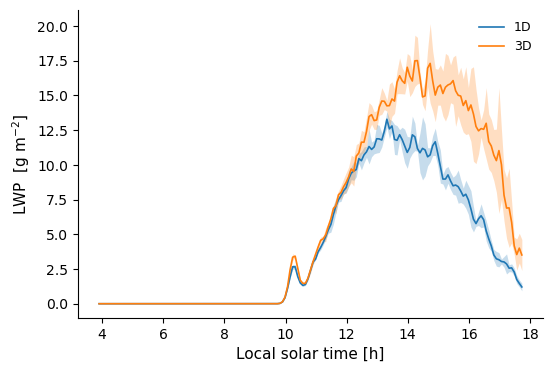

In [7]:
t_lst    = sim_time_to_lst(t_sec)
t_lst_cs = sim_time_to_lst(t_sec_cs)

fig, ax = plt.subplots(1, 1, figsize = (6, 4))
ax.plot(t_lst, lwp_1d, color='C0', lw=1.2, label='1D')
ax.fill_between(t_lst, lwp_1d - lwp_1d_std, lwp_1d + lwp_1d_std, color='C0', alpha=0.25, linewidth=0)
ax.plot(t_lst, lwp_3d, color='C1', lw=1.2, label='3D')
ax.fill_between(t_lst, lwp_3d - lwp_3d_std, lwp_3d + lwp_3d_std, color='C1', alpha=0.25, linewidth=0)
ax.set_ylabel(r'LWP  [g m$^{-2}$]', fontsize=11)
ax.set_xlabel('Local solar time [h]', fontsize=11)
ax.legend(fontsize=9, frameon=False, loc='upper right')
sns.despine()

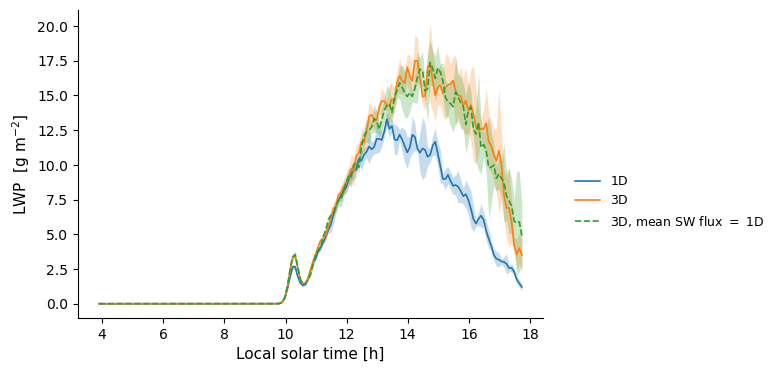

In [8]:
t_lst    = sim_time_to_lst(t_sec)
t_lst_cs = sim_time_to_lst(t_sec_cs)

fig, ax = plt.subplots(1, 1, figsize = (6, 4))
ax.plot(t_lst, lwp_1d, color='C0', lw=1.2, label='1D')
ax.fill_between(t_lst, lwp_1d - lwp_1d_std, lwp_1d + lwp_1d_std, color='C0', alpha=0.25, linewidth=0)
ax.plot(t_lst, lwp_3d, color='C1', lw=1.2, label='3D')
ax.fill_between(t_lst, lwp_3d - lwp_3d_std, lwp_3d + lwp_3d_std, color='C1', alpha=0.25, linewidth=0)
ax.set_ylabel(r'LWP  [g m$^{-2}$]', fontsize=11)
ax.set_xlabel('Local solar time [h]', fontsize=11)

# ── overlay sw_scale: 3D run with domain-mean surface SW rescaled to the 1D mean ──
sw_scale_root = CASS_ROOT / 'experiments' / 'sw_scale' / 'raytracer'
sw_dirs = sorted(d for d in sw_scale_root.glob('rep_*') if d.is_dir())
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    reps_sw = [load_stats(d) for d in sw_dirs]

nt_sw = min(s['qlqi_path'].sizes['time'] for s in reps_sw)
m     = min(len(t_lst), nt_sw)                       # align to the panel's time axis

lwp_sw_reps = np.stack([s['qlqi_path'].values[:m] * 1e3 for s in reps_sw])
lwp_sw      = lwp_sw_reps.mean(0)
lwp_sw_std  = lwp_sw_reps.std(0, ddof=0)

ax.plot(t_lst[:m], lwp_sw, color='C2', lw=1.2, ls='--',
        label='3D, mean SW flux $=$ 1D')          # heterogeneity-only (mean bias removed)
ax.fill_between(t_lst[:m], lwp_sw - lwp_sw_std, lwp_sw + lwp_sw_std,
                color='C2', alpha=0.25, linewidth=0)

ax.legend(fontsize=9, frameon=False, loc='upper right', bbox_to_anchor = (1.5, .5))

sns.despine()

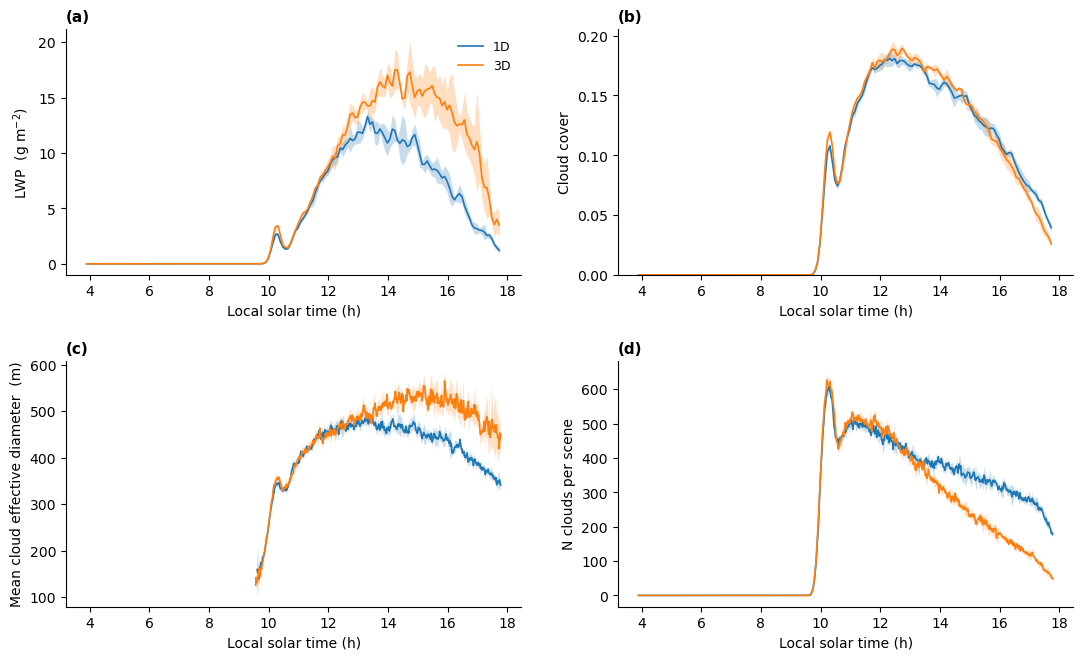

In [9]:
# ── Figure 1: bulk (row 1) + population (row 2), shared LST axis ────────────
fig = plt.figure(figsize=(13, 7.5))
gs  = fig.add_gridspec(2, 6, hspace=0.35, wspace=1.1)

ax_lwp = fig.add_subplot(gs[0, 0:3])
ax_cc  = fig.add_subplot(gs[0, 3:6], sharex=ax_lwp)
ax_L   = fig.add_subplot(gs[1, 0:3], sharex=ax_lwp)
ax_n   = fig.add_subplot(gs[1, 3:6], sharex=ax_lwp)

t_lst    = sim_time_to_lst(t_sec)
t_lst_cs = sim_time_to_lst(t_sec_cs)

def _panel(ax, t, m1, s1, m3, s3, ylbl, legend=False):
    ax.plot(t, m1, color='C0', lw=1.2, label='1D')
    ax.fill_between(t, m1 - s1, m1 + s1, color='C0', alpha=0.25, linewidth=0)
    ax.plot(t, m3, color='C1', lw=1.2, label='3D')
    ax.fill_between(t, m3 - s3, m3 + s3, color='C1', alpha=0.25, linewidth=0)
    ax.set_ylabel(ylbl)
    ax.set_xlabel('Local solar time (h)')
    if legend:
        ax.legend(fontsize=9, frameon=False, loc='upper right')

# Row 1
_panel(ax_lwp, t_lst,    lwp_1d, lwp_1d_std, lwp_3d, lwp_3d_std,
       r'LWP  (g m$^{-2}$)', legend=True)
_panel(ax_cc, t_lst,     cc_1d,  cc_1d_std,  cc_3d,  cc_3d_std,
       'Cloud cover')
ax_cc.set_ylim(bottom=0)

# Row 2
_panel(ax_L,  t_lst_cs,  mL_1d,  mL_1d_std,  mL_3d,  mL_3d_std,
       'Mean cloud effective diameter  (m)')
_panel(ax_n,  t_lst_cs,  nc_1d,  nc_1d_std,  nc_3d,  nc_3d_std,
       'N clouds per scene')

# x-tick labels visible on every panel (sharex hides them by default)
for ax in (ax_lwp, ax_cc, ax_L, ax_n):
    for lbl in ax.get_xticklabels():
        lbl.set_visible(True)

# Panel labels (a)–(d), reading order
for ax, tag in zip((ax_lwp, ax_cc, ax_L, ax_n),
                   ('(a)', '(b)', '(c)', '(d)')):
    ax.text(0.0, 1.02, tag, transform=ax.transAxes,
            ha='left', va='bottom', fontsize=11, fontweight='bold')
sns.despine()
if SAVE_PDF:
    plt.savefig('lwp_baseline.pdf', bbox_inches='tight')
    plt.savefig(f'ql_timeh_{EXPT_KEY}.pdf', bbox_inches='tight')
plt.show()


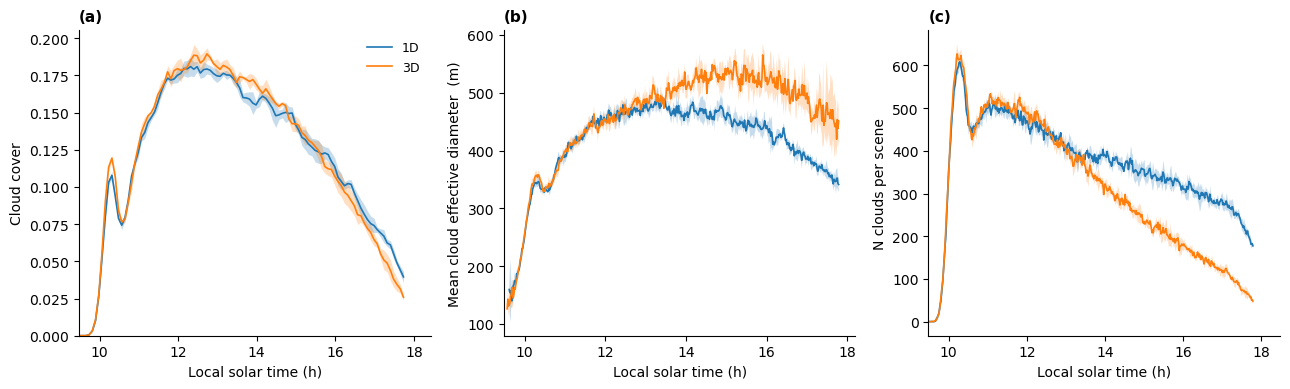

In [18]:
fig, (ax_cc, ax_L, ax_n) = plt.subplots(1, 3, figsize=(13, 4))

t_lst    = sim_time_to_lst(t_sec)
t_lst_cs = sim_time_to_lst(t_sec_cs)

# cloud-cover onset (solar time): first moment either 1D or 3D has any cloud
cc_any  = np.maximum(cc_1d, cc_3d)
t_start = t_lst[np.argmax(cc_any > 0)]          # argmax -> first True index

def _panel(ax, t, m1, s1, m3, s3, ylbl, legend=False):
    ax.plot(t, m1, color='C0', lw=1.2, label='1D')
    ax.fill_between(t, m1 - s1, m1 + s1, color='C0', alpha=0.25, linewidth=0)
    ax.plot(t, m3, color='C1', lw=1.2, label='3D')
    ax.fill_between(t, m3 - s3, m3 + s3, color='C1', alpha=0.25, linewidth=0)
    ax.set_ylabel(ylbl)
    ax.set_xlabel('Local solar time (h)')
    ax.set_xlim(left=t_start)                    # start once clouds appear
    if legend:
        ax.legend(fontsize=9, frameon=False, loc='upper right')

_panel(ax_cc, t_lst,    cc_1d, cc_1d_std, cc_3d, cc_3d_std, 'Cloud cover', legend=True)
ax_cc.set_ylim(bottom=0)
_panel(ax_L,  t_lst_cs, mL_1d, mL_1d_std, mL_3d, mL_3d_std,
       'Mean cloud effective diameter  (m)')
_panel(ax_n,  t_lst_cs, nc_1d, nc_1d_std, nc_3d, nc_3d_std, 'N clouds per scene')

for ax, tag in zip((ax_cc, ax_L, ax_n), ('(a)', '(b)', '(c)')):
    ax.text(0.0, 1.02, tag, transform=ax.transAxes,
            ha='left', va='bottom', fontsize=11, fontweight='bold')

sns.despine()
fig.tight_layout()
if SAVE_PDF:
    plt.savefig(f'cloud_population_{EXPT_KEY}.pdf', bbox_inches='tight')
plt.show()


## 2. Surface energy balance


In [5]:
# ── SEB: load ensemble stats ──────────────────────────────────────────────────
s2s_mean, s2s_std = load_stats_ensemble(rs.dirs['2stream'])
srt_mean, srt_std = load_stats_ensemble(rs.dirs['raytracer'])

print(f"2stream:   {len(rs.dirs['2stream'])} rep(s),  "
      f"t = {s2s_mean['t_local'].values[0]} → {s2s_mean['t_local'].values[-1]}")
print(f"raytracer: {len(rs.dirs['raytracer'])} rep(s),  "
      f"t = {srt_mean['t_local'].values[0]} → {srt_mean['t_local'].values[-1]}")

# ── SEB: load conditioned means (pickle cache) ────────────────────────────────
_SEB_CACHE = CASS_ROOT / 'analysis' / 'seb_cache'
_SEB_CACHE.mkdir(parents=True, exist_ok=True)

def _compute_cond(result):
    mean_d, std_d = result
    for d in (mean_d, std_d):
        for kind in d:
            d[kind] = {var: da.compute() for var, da in d[kind].items()}
    return mean_d, std_d

def _load_or_compute_conditioned(rep_dirs, cache_name, variables, force=False):
    cache_file = _SEB_CACHE / f'{cache_name}.pkl'
    if not force and cache_file.exists():
        with open(cache_file, 'rb') as fh:
            cached = pickle.load(fh)
        if 'domain' in cached[0]:
            cached_vars = set(cached[0]['domain'].keys())
            need        = set(variables)
            missing     = need - cached_vars
            if not missing:
                print(f'  [cache hit] {cache_file.name}')
                return cached
            print(f'  [stale cache — missing {sorted(missing)}] {cache_file.name}')
        else:
            print(f'  [stale cache — no domain key] {cache_file.name}')
    print(f'  [computing] {cache_name} …')
    result = _compute_cond(conditioned_means_ensemble(rep_dirs, variables=variables))
    with open(cache_file, 'wb') as fh:
        pickle.dump(result, fh)
    print(f'  [cached]    {cache_file.name}')
    return result

_slug = f'experiments_{EXPT_KEY}'
cond_2s_mean, cond_2s_std = _load_or_compute_conditioned(
    rs.dirs['2stream'],
    f'{_slug}__2stream',
    variables=['thl_fluxbot', 'qt_fluxbot', 'sw_flux_dn',
               'lw_flux_dn', 'lw_flux_up'],
)
cond_rt_mean, cond_rt_std = _load_or_compute_conditioned(
    rs.dirs['raytracer'],
    f'{_slug}__raytracer',
    variables=['thl_fluxbot', 'qt_fluxbot', 'sw_flux_sfc_rt', 'sw_flux_dn',
               'lw_flux_dn', 'lw_flux_up'],
)
print('Done.')


2stream:   4 rep(s),  t = 2005-07-24T03:53:56.400000000 → 2005-07-24T17:43:56.400000000
raytracer: 4 rep(s),  t = 2005-07-24T03:53:56.400000000 → 2005-07-24T17:43:56.400000000
  [cache hit] experiments_no_aerosols_zero_wind_v2__2stream.pkl
  [cache hit] experiments_no_aerosols_zero_wind_v2__raytracer.pkl
Done.


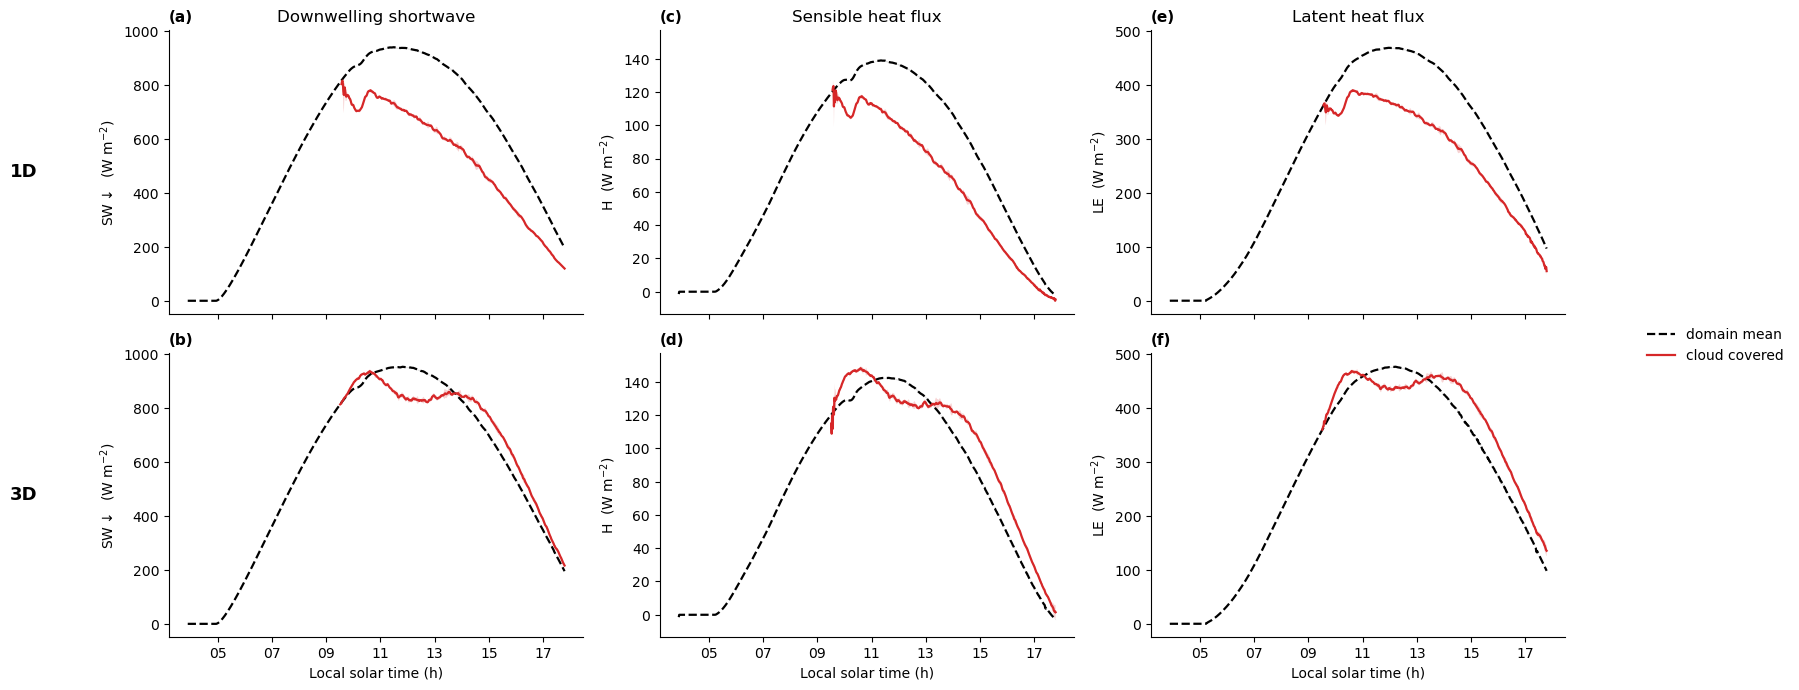

In [6]:
# ── Figure 2b: SW (domain/clear-sky/cloud-covered); H,LE (domain/cloud-covered) ──
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 3, figsize=(18, 7), sharex=True)

H_scale, LE_scale = rho * cp, rho * Lv

DM_COLOR, CLR_COLOR, CC_COLOR = 'k', 'tab:orange', 'tab:red'

rt_rows = [
    ('2stream',   cond_2s_mean, cond_2s_std, '1D'),
    ('raytracer', cond_rt_mean, cond_rt_std, '3D'),
]
col_specs = [
    ('sw_flux_sfc_rt', 'sw_flux_dn', r'SW$\downarrow$  (W m$^{-2}$)', 1.0, 'Downwelling shortwave'),
    ('thl_fluxbot',    None,         r'H  (W m$^{-2}$)',              H_scale, 'Sensible heat flux'),
    ('qt_fluxbot',     None,         r'LE  (W m$^{-2}$)',             LE_scale, 'Latent heat flux'),
]

def _line(ax, t, m, scale, color, label, ls='-', s=None, band=0.0):
    tp = _to_plottime(t); m = np.asarray(m) * scale
    ax.plot(tp, m, color=color, ls=ls, lw=1.6, label=label)
    if s is not None and band > 0:
        s = np.asarray(s) * scale
        ax.fill_between(tp, m - s, m + s, color=color, alpha=band, lw=0)

for row, (rt, cm, cs, _) in enumerate(rt_rows):
    t = cm['shaded']['thl_fluxbot'].time.values
    for col, (key_rt, key_fb, ylbl, scale, title) in enumerate(col_specs):
        ax  = axes[row, col]
        key = key_rt if key_rt in cm['shaded'] else key_fb
        if col == 0:   # SW: domain mean + clear sky + cloud covered
            _line(ax, t, cm['domain'][key],   scale, DM_COLOR,  'domain mean', ls='--',
                  s=cs['domain'].get(key),  band=0.12)
            _line(ax, t, cm['shaded'][key],   scale, CC_COLOR,  'cloud covered',
                  s=cs['shaded'].get(key),  band=0.20)
        else:          # H, LE: domain mean + cloud covered
            _line(ax, t, cm['domain'][key], scale, DM_COLOR, 'domain mean', ls='--',
                  s=cs['domain'].get(key), band=0.12)
            _line(ax, t, cm['shaded'][key], scale, CC_COLOR, 'cloud covered',
                  s=cs['shaded'].get(key), band=0.20)
        ax.set_ylabel(ylbl)
        if row == 0:
            ax.set_title(title, fontsize=12)


# shared y-limits per column (top & bottom row matched)
for col in range(3):
    lo = min(axes[0, col].get_ylim()[0], axes[1, col].get_ylim()[0])
    hi = max(axes[0, col].get_ylim()[1], axes[1, col].get_ylim()[1])
    axes[0, col].set_ylim(lo, hi)
    axes[1, col].set_ylim(lo, hi)

for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(0); lbl.set_ha('center')
for ax in axes[-1, :]:
    ax.set_xlabel('Local solar time (h)')

for row, (_, _, _, rt_label) in enumerate(rt_rows):
    axes[row, 0].annotate(rt_label, xy=(-0.35, 0.5), xycoords='axes fraction',
                          fontsize=13, fontweight='bold', ha='center', va='center')

panel_tags = [['(a)', '(c)', '(e)'], ['(b)', '(d)', '(f)']]
for r in range(2):
    for c in range(3):
        axes[r, c].text(0.0, 1.02, panel_tags[r][c], transform=axes[r, c].transAxes,
                        ha='left', va='bottom', fontsize=11, fontweight='bold')

handles, labels = axes[0, 0].get_legend_handles_labels()   # SW panel has all 3 labels
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.04, 0.5),
           fontsize=10, frameon=False)
sns.despine()
plt.tight_layout(rect=[0.04, 0, 0.92, 1])
if SAVE_PDF:
    plt.savefig('seb_conditioned_baseline.pdf', bbox_inches='tight')
plt.show()


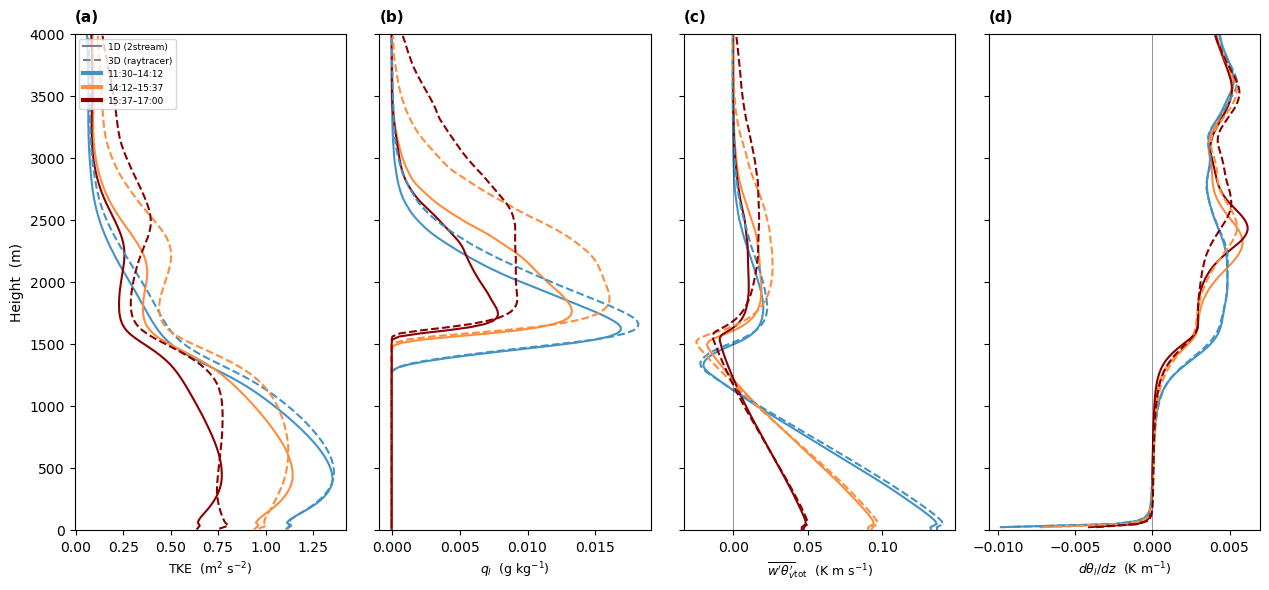

In [7]:
# ── Figure 2d: mean profiles by SZA window (1D vs 3D) ────────────────────────
# Panels: TKE, q_l, w'θ_v' (TOTAL: resolved+SGS), dθ_l/dz (inversion strength)

import pandas as pd
s2s_mean, s2s_std = load_stats_ensemble(rs.dirs['2stream'])
srt_mean, srt_std = load_stats_ensemble(rs.dirs['raytracer'])

def _lst_hours(t_local):
    t = pd.DatetimeIndex(t_local)
    return t.hour + t.minute / 60.0 + t.second / 3600.0

# (var_in_stats, zgrid, xlabel, scale, op)
# op='grad' takes d/dz of the variable; otherwise plot it directly.
PROFILE_SPECS = [
    ('tke',    'z',  r'TKE  (m$^2$ s$^{-2}$)',                        1.0,  None),
    ('ql',     'z',  r'$q_l$  (g kg$^{-1}$)',                          1e3,  None),
    ('thv_flux', 'zh', r"$\overline{w'\theta_v'}_\mathrm{tot}$  (K m s$^{-1}$)", 1.0,  None),
    ('thl',    'z',  r'$d\theta_l/dz$  (K m$^{-1}$)',                   1.0,  'grad'),
]

from sw_surface_composite import WINDOWS as SZA_WINDOWS, WINDOW_LABELS as SZA_LABELS
n_win  = len(SZA_WINDOWS)
n_vars = len(PROFILE_SPECS)
Z_MAX  = 4000  # m

fig, axes = plt.subplots(1, n_vars, figsize=(3.2 * n_vars, 6), sharey=True)

win_colors = ['#4292c6', '#fd8d3c', '#8B0000']
if n_win > len(win_colors):
    from matplotlib.cm import get_cmap
    win_colors = [get_cmap('viridis')(i / (n_win - 1)) for i in range(n_win)]

for rt, sm, ls_style, rt_lbl in [
    ('2stream',   s2s_mean, '-',  '1D'),
    ('raytracer', srt_mean, '--', '3D'),
]:
    lst_h = _lst_hours(sm['t_local'].values)
    for wi, (lst_lo, lst_hi) in enumerate(SZA_WINDOWS):
        mask = (lst_h >= lst_lo) & (lst_h <= lst_hi)
        if mask.sum() == 0:
            continue
        for col, (var, zgrid, xlabel, scale, op) in enumerate(PROFILE_SPECS):
            ax    = axes[col]
            z     = sm[zgrid].values
            prof  = sm[var].values[mask].mean(axis=0) * scale
            if op == 'grad':
                dz       = np.diff(z)
                prof_pl  = np.diff(prof) / dz
                z_plot   = 0.5 * (z[:-1] + z[1:])
            else:
                prof_pl  = prof
                z_plot   = z
            z_mask = z_plot <= Z_MAX
            label  = f'{rt_lbl} {SZA_LABELS[wi][:11]}' if col == 0 else None
            ax.plot(prof_pl[z_mask], z_plot[z_mask], color=win_colors[wi],
                    ls=ls_style, lw=1.5, label=label)
            ax.set_xlabel(xlabel, fontsize=9)

# Zero line on the buoyancy-flux and gradient panels
for col, (var, _, _, _, op) in enumerate(PROFILE_SPECS):
    if var == 'thv_flux' or op == 'grad':
        axes[col].axvline(0, color='k', lw=0.5, alpha=0.6)

axes[0].set_ylabel('Height  (m)')
axes[0].set_ylim(0, Z_MAX)

from matplotlib.lines import Line2D
rt_handles = [
    Line2D([0],[0], color='gray', ls='-',  lw=1.5, label='1D (2stream)'),
    Line2D([0],[0], color='gray', ls='--', lw=1.5, label='3D (raytracer)'),
]
win_handles = [
    Line2D([0],[0], color=win_colors[wi], ls='-', lw=3,
           label=SZA_LABELS[wi].split('(')[0].strip())
    for wi in range(n_win)
]
axes[0].legend(handles=rt_handles + win_handles, fontsize=6.5,
               loc='upper left', frameon=True)

for ax, tag in zip(axes, ('(a)', '(b)', '(c)', '(d)')):
    ax.text(0.0, 1.02, tag, transform=ax.transAxes,
            ha='left', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
if SAVE_PDF:
    plt.savefig('mean_profiles_windowed.pdf', bbox_inches='tight')
    print('Saved mean_profiles_windowed.pdf')
plt.show()


## q_l time-height cross-section

3D (raytracer), 1D (2stream), and 3D−1D domain-mean q_l, averaged over 4 reps.
Uses stats profiles loaded earlier for the SEB section.


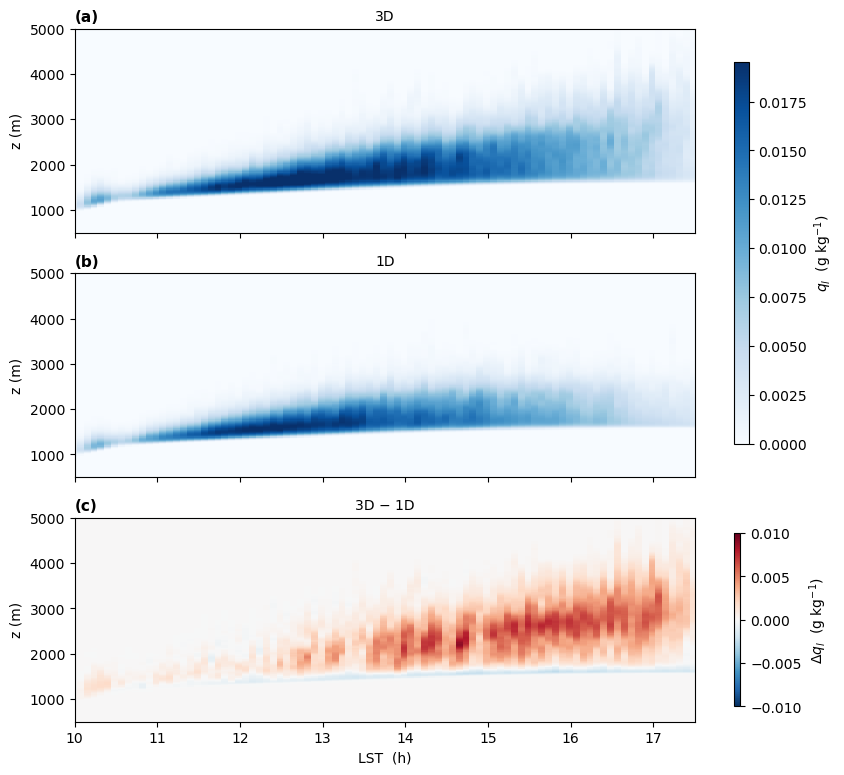

In [9]:
# ── q_l time-height cross-sections: 1D, 3D, difference ──────────────────────
z_min, z_max = 500, 5000
lst_lo, lst_hi = 10.0, 17.5

z     = srt_mean['z'].values
zmsk  = (z >= z_min) & (z <= z_max)
z_ax  = z[zmsk]

t1 = s2s_mean['t_sec'].values
t3 = srt_mean['t_sec'].values
nt = min(len(t1), len(t3))
ql_1d = s2s_mean['ql'].isel(time=slice(None, nt)).values[:, zmsk] * 1e3  # g/kg
ql_3d = srt_mean['ql'].isel(time=slice(None, nt)).values[:, zmsk] * 1e3
ql_diff = ql_3d - ql_1d
t_h = t3[:nt] / 3600.0 + LST_OFFSET

# Shared absolute colour scale (99th percentile of positive q_l)
_pos = np.concatenate([ql_3d[ql_3d > 0].ravel(), ql_1d[ql_1d > 0].ravel()])
vmax_abs = max(float(np.nanpercentile(_pos, 99)), 0.01) if _pos.size else 0.01
# Tighter 95th-percentile diff scale — brings out the cloud-top overshoot belt
_dif_flat = np.abs(ql_diff).ravel()
vmax_diff = max(float(np.nanpercentile(_dif_flat[np.isfinite(_dif_flat)], 95)), 0.01)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True, sharey=True)

pcm_abs = axes[0].pcolormesh(t_h, z_ax, ql_3d.T, cmap='Blues',
                             vmin=0, vmax=vmax_abs)
axes[1].pcolormesh(t_h, z_ax, ql_1d.T, cmap='Blues',
                   vmin=0, vmax=vmax_abs)
pcm_diff = axes[2].pcolormesh(t_h, z_ax, ql_diff.T, cmap='RdBu_r',
                              vmin=-vmax_diff, vmax=vmax_diff)

for ax, title in zip(axes, ['3D', '1D', '3D − 1D']):
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('z (m)')

axes[2].set_xlabel('LST  (h)')
axes[0].set_xlim(lst_lo, lst_hi)
axes[0].set_ylim(z_min, z_max)

fig.colorbar(pcm_abs,  ax=axes[:2].tolist(), location='right', shrink=0.85,
             aspect=25, label=r'$q_l$  (g kg$^{-1}$)')
fig.colorbar(pcm_diff, ax=axes[2], location='right', shrink=0.85,
             aspect=25, label=r'$\Delta q_l$  (g kg$^{-1}$)')

# Panel labels (a)–(c)
for ax, tag in zip(axes, ('(a)', '(b)', '(c)')):
    ax.text(0.0, 1.02, tag, transform=ax.transAxes,
            ha='left', va='bottom', fontsize=11, fontweight='bold')

if SAVE_PDF:
    plt.savefig(f'ql_timeh_{EXPT_KEY}.pdf', bbox_inches='tight')
plt.show()


(rt=2stream, var=sw) ...


  -> n_total=562,036,736  cache=/pscratch/sd/m/mpowell/CASS_LES/analysis/cache/sfc_pdf/no_aerosols_zero_wind_v2/2stream_sw.pkl
(rt=raytracer, var=sw) ...
  -> n_total=251,920,384  cache=/pscratch/sd/m/mpowell/CASS_LES/analysis/cache/sfc_pdf/no_aerosols_zero_wind_v2/raytracer_sw.pkl
(rt=2stream, var=thl_fluxbot) ...
  -> n_total=562,036,736  cache=/pscratch/sd/m/mpowell/CASS_LES/analysis/cache/sfc_pdf/no_aerosols_zero_wind_v2/2stream_thl_fluxbot.pkl
(rt=raytracer, var=thl_fluxbot) ...
  -> n_total=502,005,760  cache=/pscratch/sd/m/mpowell/CASS_LES/analysis/cache/sfc_pdf/no_aerosols_zero_wind_v2/raytracer_thl_fluxbot.pkl
(rt=2stream, var=qt_fluxbot) ...
  -> n_total=562,036,736  cache=/pscratch/sd/m/mpowell/CASS_LES/analysis/cache/sfc_pdf/no_aerosols_zero_wind_v2/2stream_qt_fluxbot.pkl
(rt=raytracer, var=qt_fluxbot) ...
  -> n_total=502,005,760  cache=/pscratch/sd/m/mpowell/CASS_LES/analysis/cache/sfc_pdf/no_aerosols_zero_wind_v2/raytracer_qt_fluxbot.pkl
(rt=2stream, var=b) ...
  -> n_to

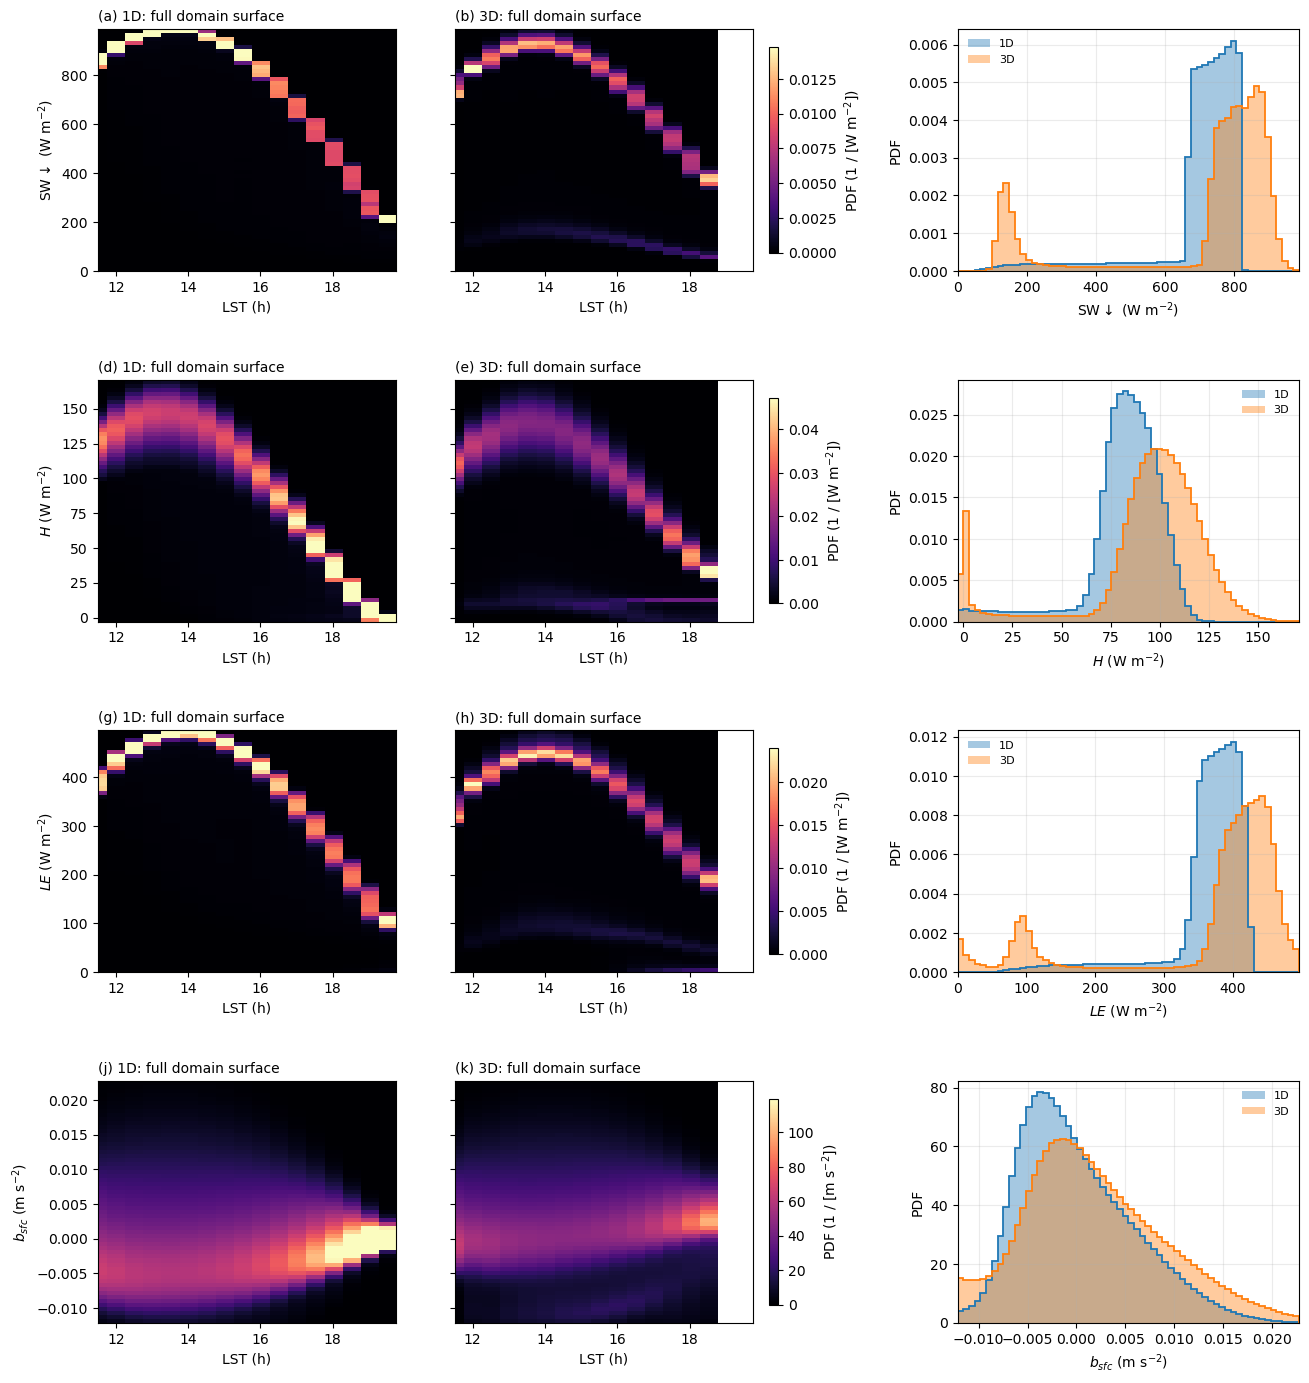

In [16]:
# ── PDF(LST) of unconditioned surface b, H, LE  (1D vs 3D) ───────────────
# Reads xy cross-sections (b, thl_fluxbot, qt_fluxbot) one (rt,var) at a time,
# caches per-LST density + percentile curves + the single-LST sample for the
# RHS panel. Re-running uses the cache (no xy reload).
# H  = rho * cp * thl_fluxbot     LE = rho * Lv * qt_fluxbot
import xarray as xr
import pandas as pd
import pickle, gc

LES_ROOT_V2      = Path('/pscratch/sd/m/mpowell/CASS_LES/experiments') / V2_EXPT
SFC_CACHE_DIR    = Path('/pscratch/sd/m/mpowell/CASS_LES/analysis/cache/sfc_pdf') / V2_EXPT
SFC_CACHE_DIR.mkdir(parents=True, exist_ok=True)

LST_CENTERS_HRES = np.arange(11.0, 19.51, 0.5)   # 30-min bins for heatmap x-axis
HALF_HR          = 0.25                          # +/- 15 min window
LST_TARGET_LOC   = 16.5
N_PDF_BINS       = 60

def _get_local_start(rd):
    from cass_analysis import get_local_start
    return get_local_start(rd)

def _lst_array_from_t(t_sec, start):
    if start is None:
        return t_sec / 3600.0
    t_lcl = pd.to_datetime([start + pd.Timedelta(seconds=float(s)) for s in t_sec])
    if hasattr(t_lcl, 'tz') and t_lcl.tz is not None:
        t_lcl = t_lcl.tz_localize(None)
    return t_lcl.hour + t_lcl.minute/60 + t_lcl.second/3600

def _load_xy_var(rt, rd, var):
    # Returns (values, time_array) for one rep, or (None, None) if missing.
    # 'sw' is rt-specific: 1D uses sw_flux_dn; 3D = dir + dif.
    if var == 'sw':
        if rt == '2stream':
            f = rd / 'sw_flux_dn.xy.nc'
            if not f.exists(): return None, None
            d = xr.open_dataset(f, decode_times=False)
            v = d['sw_flux_dn'].values.astype(np.float32)
            t = d.time.values; d.close()
        else:
            f1 = rd / 'sw_flux_sfc_dir_rt.xy.nc'
            f2 = rd / 'sw_flux_sfc_dif_rt.xy.nc'
            if not (f1.exists() and f2.exists()): return None, None
            d1 = xr.open_dataset(f1, decode_times=False)
            d2 = xr.open_dataset(f2, decode_times=False)
            v  = (d1['sw_flux_sfc_dir_rt'].values
                  + d2['sw_flux_sfc_dif_rt'].values).astype(np.float32)
            t  = d1.time.values
            d1.close(); d2.close()
        return v, t
    f = rd / f'{var}.xy.nc'
    if not f.exists(): return None, None
    d = xr.open_dataset(f, decode_times=False)
    v = d[var].values.astype(np.float32)
    t = d.time.values; d.close()
    return v, t

def _compute_sfc_pool(rt, var, scale, n_reps=N_REPS):
    # Pool xy data across reps for one (rt, var) and return:
    #   edges, density(NLST,NBIN), p50/p75/p95(NLST,), target_sample (for RHS PDF)
    cache = SFC_CACHE_DIR / f'{rt}_{var}.pkl'
    if cache.exists():
        with open(cache,'rb') as f: return pickle.load(f)

    # ---- pass 1: figure out bin edges (load percentiles only) ---------------
    print(f'  pass1 ({rt} {var}): loading min/max across reps ...', flush=True)
    sample_lo, sample_hi = [], []
    pooled_for_edges = []
    for ri in range(1, n_reps+1):
        rd = LES_ROOT_V2 / rt / f'rep_{ri:02d}'
        v, _t = _load_xy_var(rt, rd, var)
        if v is None: continue
        v = (v * scale).astype(np.float32)
        flat = v.reshape(-1)
        stride = max(1, flat.size // 1_000_000)
        pooled_for_edges.append(flat[::stride])
        del v
    if not pooled_for_edges:
        return None
    pooled_for_edges = np.concatenate(pooled_for_edges)
    pooled_for_edges = pooled_for_edges[np.isfinite(pooled_for_edges)]
    lo, hi = np.percentile(pooled_for_edges, [0.5, 99.9])
    edges = np.linspace(lo, hi, N_PDF_BINS+1)
    del pooled_for_edges; gc.collect()

    # ---- pass 2: per-rep streaming accumulation ----------------------------
    print(f'  pass2 ({rt} {var}): streaming hist + percentile per LST bin ...', flush=True)
    nlst = LST_CENTERS_HRES.size
    nbin = edges.size - 1
    hist_acc  = np.zeros((nlst, nbin), dtype=np.int64)
    cnt_acc   = np.zeros(nlst, dtype=np.int64)
    per_lst_samples = [[] for _ in range(nlst)]   # for percentile (small lists per LST bin)
    target_sample = []                            # pooled values within LST_TARGET_LOC +/- 0.5

    for ri in range(1, n_reps+1):
        rd = LES_ROOT_V2 / rt / f'rep_{ri:02d}'
        v, t = _load_xy_var(rt, rd, var)
        if v is None: continue
        v   = (v * scale).astype(np.float32)
        lst = _lst_array_from_t(t, _get_local_start(rd))

        # For each LST bin, contribute hist and sub-sample for percentile.
        # Subsample for percentile: max 1M values per LST bin to stay memory-safe.
        for j, lc in enumerate(LST_CENTERS_HRES):
            m = np.abs(lst - lc) <= HALF_HR
            if not m.any(): continue
            block = v[m].ravel()
            block = block[np.isfinite(block)]
            if block.size == 0: continue
            h, _ = np.histogram(block, bins=edges)
            hist_acc[j] += h
            cnt_acc[j]  += block.size
            # downsample for percentile (target ~500k per LST bin per rep)
            stride = max(1, block.size // 500_000)
            per_lst_samples[j].append(block[::stride].copy())

        # collect the target-LST sample for RHS
        m_t = np.abs(lst - LST_TARGET_LOC) <= 0.5
        if m_t.any():
            block = v[m_t].ravel()
            stride = max(1, block.size // 4_000_000)
            target_sample.append(block[::stride].astype(np.float32).copy())

        del v, t, lst; gc.collect()

    # density per LST row (normalised over value axis)
    bin_w = np.diff(edges)
    density = np.full((nlst, nbin), np.nan)
    for j in range(nlst):
        if cnt_acc[j] > 0:
            density[j] = hist_acc[j] / (cnt_acc[j] * bin_w)

    p50 = np.full(nlst, np.nan); p75 = np.full(nlst, np.nan); p95 = np.full(nlst, np.nan)
    for j in range(nlst):
        if per_lst_samples[j]:
            arr = np.concatenate(per_lst_samples[j])
            arr = arr[np.isfinite(arr)]
            if arr.size >= 50:
                p50[j] = np.percentile(arr,50)
                p75[j] = np.percentile(arr,75)
                p95[j] = np.percentile(arr,95)

    target_sample = (np.concatenate(target_sample)
                     if target_sample else np.array([], np.float32))
    target_sample = target_sample[np.isfinite(target_sample)]

    out = dict(edges=edges, density=density, p50=p50, p75=p75, p95=p95,
               target_sample=target_sample, n_total=int(cnt_acc.sum()))
    with open(cache,'wb') as f: pickle.dump(out, f)
    return out


QUANTS = [
    ('sw',          r'SW$\downarrow$ (W m$^{-2}$)',  1.0     ),
    ('thl_fluxbot', r'$H$ (W m$^{-2}$)',               rho * cp ),
    ('qt_fluxbot',  r'$LE$ (W m$^{-2}$)',              rho * Lv ),
    ('b',           r'$b_{sfc}$ (m s$^{-2}$)',         1.0     ),
]

results = {}
for var, _, scale in QUANTS:
    results[var] = {}
    for rt in ('2stream','raytracer'):
        print(f'(rt={rt}, var={var}) ...', flush=True)
        r = _compute_sfc_pool(rt, var, scale)
        results[var][rt] = r
        if r is None:
            print(f'  -> no .xy.nc; skipped')
        else:
            print(f'  -> n_total={r["n_total"]:,}  cache='
                  f'{SFC_CACHE_DIR / f"{rt}_{var}.pkl"}')
        gc.collect()

n_rows = len(QUANTS)
fig = plt.figure(figsize=(15.5, 4.2 * n_rows))
gs  = fig.add_gridspec(n_rows, 3, wspace=0.20, hspace=0.45,
                       width_ratios=[1.0, 1.0, 0.95])
panel_lab_letters = 'abcdefghijkl'

for r, (var, xlbl, _) in enumerate(QUANTS):
    # determine extent / vmax from whichever RTs have data
    have = [rt for rt in ('2stream','raytracer') if results[var][rt] is not None]
    if not have:
        for c_i in range(3):
            ax = fig.add_subplot(gs[r, c_i])
            ax.text(0.5, 0.5, 'no data', ha='center', va='center')
        continue
    edges = results[var][have[0]]['edges']
    extent = [LST_CENTERS_HRES[0] - HALF_HR, LST_CENTERS_HRES[-1] + HALF_HR,
              edges[0], edges[-1]]
    vmax = float(np.nanpercentile(np.concatenate(
        [results[var][rt]['density'].ravel() for rt in have]), 99))

    ax_1d = fig.add_subplot(gs[r, 0])
    ax_3d = fig.add_subplot(gs[r, 1], sharey=ax_1d)
    ax_pdf= fig.add_subplot(gs[r, 2])
    im = None

    for col, rt in enumerate(('2stream','raytracer')):
        ax  = (ax_1d, ax_3d)[col]
        res = results[var][rt]
        if res is None:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='gray'); continue
        im = ax.imshow(res['density'].T, origin='lower', aspect='auto', extent=extent,
                       cmap='magma', vmin=0, vmax=vmax, interpolation='nearest')
        ax.set_xlabel('LST (h)')
        ax.set_ylim(edges[0], edges[-1])
        ax.set_xlim(11.5, None)

    lab_a = f'({panel_lab_letters[3*r + 0]})'
    lab_b = f'({panel_lab_letters[3*r + 1]})'
    lab_c = f'({panel_lab_letters[3*r + 2]})'
    ax_1d.set_title(f'{lab_a} 1D: full domain surface', loc='left', fontsize=10)
    ax_3d.set_title(f'{lab_b} 3D: full domain surface', loc='left', fontsize=10)
    ax_1d.set_ylabel(xlbl)
    plt.setp(ax_3d.get_yticklabels(), visible=False)
    pdf_unit = '1 / [' + xlbl.split('(')[-1].rstrip(')') + ']'
    if im is not None:
        fig.colorbar(im, ax=[ax_1d, ax_3d], shrink=0.85, aspect=22, pad=0.02,
                     label=f'PDF ({pdf_unit})')

    for rt, color in [('2stream','C0'),('raytracer','C1')]:
        res = results[var][rt]
        if res is None or res['target_sample'].size == 0: continue
        x = res['target_sample']
        rt_lbl = '1D' if rt == '2stream' else '3D'
        ax_pdf.hist(x, bins=edges, density=True, color=color, alpha=0.40,
                    histtype='stepfilled', label=f'{rt_lbl}')
        ax_pdf.hist(x, bins=edges, density=True, color=color, histtype='step', lw=1.3)

    ax_pdf.set_xlabel(xlbl)
    ax_pdf.set_ylabel('PDF')
    ax_pdf.legend(fontsize=8, frameon=False)
    ax_pdf.grid(alpha=0.25)
    ax_pdf.set_xlim(edges[0], edges[-1])

if SAVE_PDF:
    plt.savefig(f'sfc_pdf_unconditioned_{V2_EXPT}.pdf', bbox_inches='tight')
plt.show()


(rt=2stream, var=sw) cloud-covered ...


  -> n_total=65,763,083
(rt=raytracer, var=sw) cloud-covered ...
  -> n_total=31,607,991
(rt=2stream, var=thl_fluxbot) cloud-covered ...
  -> n_total=65,763,083
(rt=raytracer, var=thl_fluxbot) cloud-covered ...
  -> n_total=31,607,991
(rt=2stream, var=qt_fluxbot) cloud-covered ...
  -> n_total=65,763,083
(rt=raytracer, var=qt_fluxbot) cloud-covered ...
  -> n_total=31,607,991
(rt=2stream, var=b) cloud-covered ...
  -> n_total=65,763,083
(rt=raytracer, var=b) cloud-covered ...
  -> n_total=31,607,991


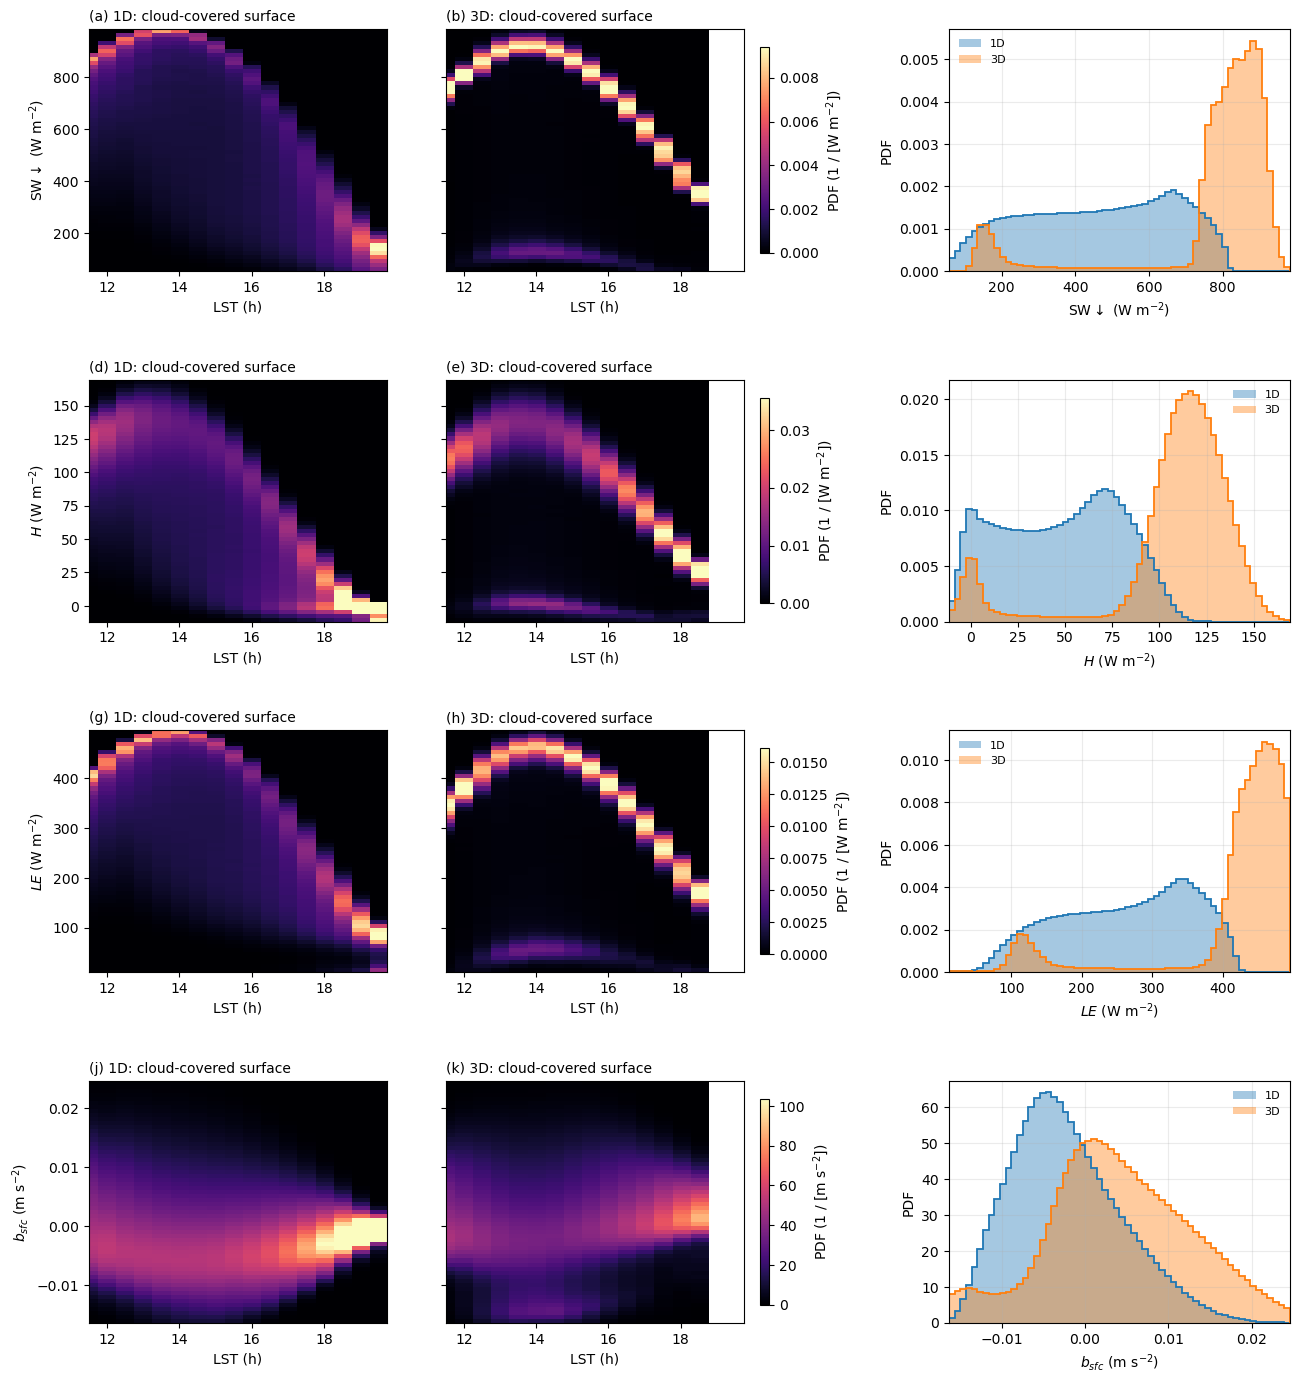

In [17]:
# ── PDF(LST) of cloud-covered surface SW, H, LE, b  (1D vs 3D) ─────────
# Conditions on qlqi_path > 0 per (t,y,x): a column is "cloud-covered" if
# any liquid+ice water sits above it.  Drops every non-cloud-covered column.
# Caches per (rt, var) under cache/sfc_pdf_cc/.
import xarray as xr
import pandas as pd
import pickle, gc

LES_ROOT_V2      = Path('/pscratch/sd/m/mpowell/CASS_LES/experiments') / V2_EXPT
SFC_CC_CACHE_DIR = Path('/pscratch/sd/m/mpowell/CASS_LES/analysis/cache/sfc_pdf_cc') / V2_EXPT
SFC_CC_CACHE_DIR.mkdir(parents=True, exist_ok=True)

LST_CENTERS_HRES = np.arange(11.0, 19.51, 0.5)
HALF_HR          = 0.25
LST_TARGET_LOC   = 16.5
N_PDF_BINS       = 60

def _local_start_cc(rd):
    from cass_analysis import get_local_start
    return get_local_start(rd)

def _lst_from_t_cc(t_sec, start):
    if start is None: return t_sec / 3600.0
    t_lcl = pd.to_datetime([start + pd.Timedelta(seconds=float(s)) for s in t_sec])
    if hasattr(t_lcl, 'tz') and t_lcl.tz is not None:
        t_lcl = t_lcl.tz_localize(None)
    return t_lcl.hour + t_lcl.minute/60 + t_lcl.second/3600

def _load_xy_var_cc(rt, rd, var):
    if var == 'sw':
        if rt == '2stream':
            f = rd / 'sw_flux_dn.xy.nc'
            if not f.exists(): return None, None
            d = xr.open_dataset(f, decode_times=False)
            v = np.squeeze(d['sw_flux_dn'].values).astype(np.float32)
            t = d.time.values; d.close()
        else:
            f1 = rd / 'sw_flux_sfc_dir_rt.xy.nc'
            f2 = rd / 'sw_flux_sfc_dif_rt.xy.nc'
            if not (f1.exists() and f2.exists()): return None, None
            d1 = xr.open_dataset(f1, decode_times=False)
            d2 = xr.open_dataset(f2, decode_times=False)
            v  = np.squeeze(d1['sw_flux_sfc_dir_rt'].values
                            + d2['sw_flux_sfc_dif_rt'].values).astype(np.float32)
            t  = d1.time.values
            d1.close(); d2.close()
        return v, t
    f = rd / f'{var}.xy.nc'
    if not f.exists(): return None, None
    d = xr.open_dataset(f, decode_times=False)
    v = np.squeeze(d[var].values).astype(np.float32)
    t = d.time.values; d.close()
    return v, t

def _load_cloud_mask_cc(rd):
    f = rd / 'qlqi_path.xy.nc'
    if not f.exists(): return None, None
    d = xr.open_dataset(f, decode_times=False)
    qlqi = d['qlqi_path'].values; t = d.time.values; d.close()
    return qlqi, t

def _compute_sfc_pool_cc(rt, var, scale, n_reps=N_REPS):
    cache = SFC_CC_CACHE_DIR / f'{rt}_{var}_cloudcov.pkl'
    if cache.exists():
        with open(cache,'rb') as f: return pickle.load(f)

    # pass 1: bin edges from cloud-covered subset
    print(f'  pass1 ({rt} {var}) edges ...', flush=True)
    pooled = []
    for ri in range(1, n_reps+1):
        rd = LES_ROOT_V2 / rt / f'rep_{ri:02d}'
        v, _ = _load_xy_var_cc(rt, rd, var)
        if v is None: continue
        qlqi, _ = _load_cloud_mask_cc(rd)
        if qlqi is None: continue
        nt = min(v.shape[0], qlqi.shape[0])
        sel = (v[:nt] * scale)[qlqi[:nt] > 0].astype(np.float32)
        stride = max(1, sel.size // 1_000_000)
        pooled.append(sel[::stride])
        del v, qlqi, sel
    if not pooled: return None
    pooled = np.concatenate(pooled); pooled = pooled[np.isfinite(pooled)]
    lo, hi = np.percentile(pooled, [0.5, 99.9])
    edges = np.linspace(lo, hi, N_PDF_BINS+1)
    del pooled; gc.collect()

    # pass 2: streaming hist + LST-target sample, cloud-covered only
    print(f'  pass2 ({rt} {var}) hist ...', flush=True)
    nlst = LST_CENTERS_HRES.size
    nbin = edges.size - 1
    hist_acc = np.zeros((nlst, nbin), dtype=np.int64)
    cnt_acc  = np.zeros(nlst, dtype=np.int64)
    target_sample = []

    for ri in range(1, n_reps+1):
        rd = LES_ROOT_V2 / rt / f'rep_{ri:02d}'
        v, t = _load_xy_var_cc(rt, rd, var)
        if v is None: continue
        qlqi, _ = _load_cloud_mask_cc(rd)
        if qlqi is None: continue
        nt = min(v.shape[0], qlqi.shape[0])
        v = v[:nt] * scale; qlqi = qlqi[:nt]; t = t[:nt]
        cc_mask = qlqi > 0
        lst = _lst_from_t_cc(t, _local_start_cc(rd))

        for j, lc in enumerate(LST_CENTERS_HRES):
            tm = np.abs(lst - lc) <= HALF_HR
            if not tm.any(): continue
            block = v[tm][cc_mask[tm]]
            block = block[np.isfinite(block)]
            if block.size == 0: continue
            h, _ = np.histogram(block, bins=edges)
            hist_acc[j] += h
            cnt_acc[j]  += block.size

        m_t = np.abs(lst - LST_TARGET_LOC) <= 0.5
        if m_t.any():
            block = v[m_t][cc_mask[m_t]]
            stride = max(1, block.size // 4_000_000)
            target_sample.append(block[::stride].astype(np.float32).copy())

        del v, t, lst, qlqi, cc_mask; gc.collect()

    bin_w = np.diff(edges)
    density = np.full((nlst, nbin), np.nan)
    for j in range(nlst):
        if cnt_acc[j] > 0:
            density[j] = hist_acc[j] / (cnt_acc[j] * bin_w)
    target_sample = (np.concatenate(target_sample)
                     if target_sample else np.array([], np.float32))
    target_sample = target_sample[np.isfinite(target_sample)]

    out = dict(edges=edges, density=density,
               target_sample=target_sample, n_total=int(cnt_acc.sum()))
    with open(cache,'wb') as f: pickle.dump(out, f)
    return out


QUANTS = [
    ('sw',          r'SW$\downarrow$ (W m$^{-2}$)',  1.0     ),
    ('thl_fluxbot', r'$H$ (W m$^{-2}$)',               rho * cp ),
    ('qt_fluxbot',  r'$LE$ (W m$^{-2}$)',              rho * Lv ),
    ('b',           r'$b_{sfc}$ (m s$^{-2}$)',         1.0     ),
]

results = {}
for var, _, scale in QUANTS:
    results[var] = {}
    for rt in ('2stream','raytracer'):
        print(f'(rt={rt}, var={var}) cloud-covered ...', flush=True)
        r = _compute_sfc_pool_cc(rt, var, scale)
        results[var][rt] = r
        print(f'  -> n_total={r["n_total"]:,}' if r else '  -> skipped')
        gc.collect()

n_rows = len(QUANTS)
fig = plt.figure(figsize=(15.5, 4.2 * n_rows))
gs  = fig.add_gridspec(n_rows, 3, wspace=0.20, hspace=0.45,
                       width_ratios=[1.0, 1.0, 0.95])
panel_lab_letters = 'abcdefghijkl'

for r, (var, xlbl, _) in enumerate(QUANTS):
    have = [rt for rt in ('2stream','raytracer') if results[var][rt] is not None]
    if not have:
        for c_i in range(3):
            ax = fig.add_subplot(gs[r, c_i])
            ax.text(0.5, 0.5, 'no data', ha='center', va='center')
        continue
    edges  = results[var][have[0]]['edges']
    extent = [LST_CENTERS_HRES[0] - HALF_HR, LST_CENTERS_HRES[-1] + HALF_HR,
              edges[0], edges[-1]]
    vmax = float(np.nanpercentile(np.concatenate(
        [results[var][rt]['density'].ravel() for rt in have]), 99))

    ax_1d  = fig.add_subplot(gs[r, 0])
    ax_3d  = fig.add_subplot(gs[r, 1], sharey=ax_1d)
    ax_pdf = fig.add_subplot(gs[r, 2])
    im = None
    for col, rt in enumerate(('2stream','raytracer')):
        ax  = (ax_1d, ax_3d)[col]
        res = results[var][rt]
        if res is None:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='gray'); continue
        im = ax.imshow(res['density'].T, origin='lower', aspect='auto',
                       extent=extent, cmap='magma', vmin=0, vmax=vmax,
                       interpolation='nearest')
        ax.set_xlabel('LST (h)')
        ax.set_ylim(edges[0], edges[-1])
        ax.set_xlim(11.5, None)

    la = f'({panel_lab_letters[3*r+0]})'
    lb = f'({panel_lab_letters[3*r+1]})'
    lc = f'({panel_lab_letters[3*r+2]})'
    ax_1d.set_title(f'{la} 1D: cloud-covered surface', loc='left', fontsize=10)
    ax_3d.set_title(f'{lb} 3D: cloud-covered surface', loc='left', fontsize=10)
    ax_1d.set_ylabel(xlbl)
    plt.setp(ax_3d.get_yticklabels(), visible=False)
    pdf_unit = '1 / [' + xlbl.split('(')[-1].rstrip(')') + ']'
    if im is not None:
        fig.colorbar(im, ax=[ax_1d, ax_3d], shrink=0.85, aspect=22, pad=0.02,
                     label=f'PDF ({pdf_unit})')

    for rt, color in [('2stream','C0'),('raytracer','C1')]:
        res = results[var][rt]
        if res is None or res['target_sample'].size == 0: continue
        x = res['target_sample']
        ax_pdf.hist(x, bins=edges, density=True, color=color, alpha=0.40,
                    histtype='stepfilled', label='1D' if rt=='2stream' else '3D')
        ax_pdf.hist(x, bins=edges, density=True, color=color,
                    histtype='step', lw=1.3)
    ax_pdf.set_xlabel(xlbl); ax_pdf.set_ylabel('PDF')
    ax_pdf.legend(fontsize=8, frameon=False)
    ax_pdf.grid(alpha=0.25)
    ax_pdf.set_xlim(edges[0], edges[-1])

if SAVE_PDF:
    plt.savefig(f'sfc_pdf_cloudcovered_{V2_EXPT}.pdf', bbox_inches='tight')
plt.show()


## 3. Cloud-root shadow composites

Cloud objects with chord ≥ 1 km, 11:30–17:00 LST, composited in coordinates
**rotated into solar-azimuth parallel / perpendicular**.

Three equal-θ_z SZA windows (from `sw_surface_composite.compute_equal_zenith_windows`).

Layout (per window): 3D cloud-root circulation (top) + 3D − 1D difference
(middle) + surface SW↓ anomaly (bottom). The 1D row is omitted because 1D
2stream has no azimuthal preference by construction — any structure it
carries is absorbed into the diff.


In [19]:
# ── §3 imports + data loaders ───────────────────────────────────────────────
sys.path.insert(0, str(_HERE / 'cloud_roots'))

from cass_analysis import (
    plot_cloud_root_composite, plot_circulation_composite,
    load_sfc_sw_dn, XL_GRID,
)
from cloud_root_composite_average import (
    average_reps, average_reps_windowed, average_reps_azimuth,
)
from sw_surface_composite import WINDOWS as SZA_WINDOWS, WINDOW_LABELS as SZA_LABELS

COMPOSITE_ROOT = str(CASS_ROOT / 'analysis' / 'cloud_root_composite')

print(f'SZA windows ({len(SZA_WINDOWS)}):')
for i, (w, l) in enumerate(zip(SZA_WINDOWS, SZA_LABELS)):
    print(f'  {i}: LST {w[0]:.2f}–{w[1]:.2f}  |  {l}')


SZA windows (3):
  0: LST 11.50–14.20  |  11:30–14:12  (θ_z 17–33°)
  1: LST 14.20–15.62  |  14:12–15:37  (θ_z 33–50°)
  2: LST 15.62–17.00  |  15:37–17:00  (θ_z 50–67°)


In [31]:
# ── Load windowed + azimuth composites, and sw_composite cache ─────────────
comp_windowed = {}
for case in CASES:
    print(f"\n{RT_LABEL[case['rt']]} (windowed):")
    comp_windowed[case['key']] = average_reps_windowed(
        Path(COMPOSITE_ROOT), case['comp_expt'], case['comp_rt'],
        windows=SZA_WINDOWS, window_labels=SZA_LABELS,
        n_reps=N_REPS, verbose=True,
    )

comp_az_data = {}
for case in CASES:
    print(f"\n{RT_LABEL[case['rt']]} (azimuth):")
    comp_az_data[case['key']] = average_reps_azimuth(
        Path(COMPOSITE_ROOT), case['comp_expt'], case['comp_rt'],
        windows=SZA_WINDOWS, window_labels=SZA_LABELS,
        n_reps=N_REPS, verbose=True,
    )

sw_data = {}
for case in CASES:
    rt, key = case['comp_rt'], case['key']
    Q_xz_reps, Q_yz_reps, Q_dm_reps = [], [], []
    for i in range(1, N_REPS + 1):
        nc = Path(COMPOSITE_ROOT) / EXPT_KEY / rt / f'rep_{i:02d}' / 'sw_composite.nc'
        if not nc.exists():
            continue
        with xr.open_dataset(nc) as ds_sw:
            if 'Q_mean_xz' in ds_sw:     Q_xz_reps.append(ds_sw['Q_mean_xz'].values)
            if 'Q_mean_yz' in ds_sw:     Q_yz_reps.append(ds_sw['Q_mean_yz'].values)
            if 'Q_domain_mean' in ds_sw: Q_dm_reps.append(ds_sw['Q_domain_mean'].values)
    _ens = lambda reps: None if not reps else np.nanmean(np.stack(reps), axis=0)
    sw_data[key] = dict(Q_xz=_ens(Q_xz_reps), Q_yz=_ens(Q_yz_reps),
                        Q_domain_mean=_ens(Q_dm_reps))
    print(f'sw_data[{key}]: {len(Q_xz_reps)} rep(s)')



1D (2stream) (windowed):


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:187: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)


  xz  rep_01  win 0 (11:30–14:12  (θ_z 17–33°)): 106 events
  xz  rep_01  win 1 (14:12–15:37  (θ_z 33–50°)): 33 events
  xz  rep_01  win 2 (15:37–17:00  (θ_z 50–67°)): 35 events


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:187: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)


  xz  rep_02  win 0 (11:30–14:12  (θ_z 17–33°)): 123 events
  xz  rep_02  win 1 (14:12–15:37  (θ_z 33–50°)): 29 events
  xz  rep_02  win 2 (15:37–17:00  (θ_z 50–67°)): 43 events


...

/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:187: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)


  yz  rep_03  win 0 (11:30–14:12  (θ_z 17–33°)): 143 events
  yz  rep_03  win 1 (14:12–15:37  (θ_z 33–50°)): 33 events
  yz  rep_03  win 2 (15:37–17:00  (θ_z 50–67°)): 43 events


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:187: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)


  yz  rep_04  win 0 (11:30–14:12  (θ_z 17–33°)): 102 events
  yz  rep_04  win 1 (14:12–15:37  (θ_z 33–50°)): 32 events
  yz  rep_04  win 2 (15:37–17:00  (θ_z 50–67°)): 39 events
  win 0 (11:30–14:12  (θ_z 17–33°)): φ_az=217° (LST midpoint=12.85h)
  win 1 (14:12–15:37  (θ_z 33–50°)): φ_az=258° (LST midpoint=14.91h)
  win 2 (15:37–17:00  (θ_z 50–67°)): φ_az=272° (LST midpoint=16.31h)
sw_data[1D]: 4 rep(s)
sw_data[3D]: 4 rep(s)


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:210: RuntimeWarning: Mean of empty slice
  np.nanmean(stack, axis=0), dims=["z_nd", "xL"])
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [32]:
# ── §3 helper functions (diff circulation + SW blending + global limits) ──
def _plot_diff_circulation(ax, ds_3d, ds_1d, vlim_b, orient='xz',
                           show_xlabel=True, quiver_stride=(10, 5),
                           quiver_scale=None):
    xL   = ds_3d.xL.values
    z_nd = ds_3d.z_nd.values
    b_diff = ds_3d['b_prime_mean'].values - ds_1d['b_prime_mean'].values
    u_diff = ds_3d['horiz_wind_prime_mean'].values - ds_1d['horiz_wind_prime_mean'].values
    w_diff = ds_3d['w_prime_mean'].values - ds_1d['w_prime_mean'].values
    pcm = ax.pcolormesh(xL, z_nd, b_diff, cmap='RdBu_r', shading='auto',
                        vmin=vlim_b[0], vmax=vlim_b[1])
    sx, sz = quiver_stride
    xi = np.arange(0, len(xL), sx); zi = np.arange(0, len(z_nd), sz)
    Xq, Zq = np.meshgrid(xL[xi], z_nd[zi])
    Uq = u_diff[np.ix_(zi, xi)]; Wq = w_diff[np.ix_(zi, xi)]
    qkw = dict(pivot='mid', color='k', linewidth=0.4, alpha=0.75)
    if quiver_scale is not None: qkw['scale'] = quiver_scale
    ax.quiver(Xq, Zq, Uq, Wq, **qkw)
    ax.axvline(-0.5, color='0.4', lw=0.8, ls='--'); ax.axvline(0.5, color='0.4', lw=0.8, ls='--')
    ax.axhline(1.0, color='0.4', lw=0.8, ls=':')
    ax.set_xlim(-1, 1); ax.set_ylim(0, 1.0)
    if show_xlabel: ax.set_xlabel('x/L' if orient == 'xz' else 'y/L')
    return pcm


def _blend_sw(sd, sp, cp, direction):
    Qx, Qy = sd.get('Q_xz'), sd.get('Q_yz')
    if Qx is None or Qy is None:
        return None
    if direction == 'parallel':
        return sp**2 * Qx + cp**2 * Qy
    return cp**2 * Qx + sp**2 * Qy


def _compute_global_limits_az(comp_az_data):
    n_win = len(SZA_WINDOWS)
    all_b, all_mag = [], []
    for wi in range(n_win):
        d1 = comp_az_data.get('1D', {}).get(wi, {})
        d3 = comp_az_data.get('3D', {}).get(wi, {})
        for direction in ('parallel', 'perpendicular'):
            ds3 = d3.get(direction); ds1 = d1.get(direction)
            if ds3 is None or 'b_prime_mean' not in ds3:
                continue
            all_b.append(ds3['b_prime_mean'].values.ravel())
            all_mag.append(np.sqrt(ds3['horiz_wind_prime_mean'].values**2
                                    + ds3['w_prime_mean'].values**2).ravel())
            if ds1 is not None and 'b_prime_mean' in ds1:
                b_d = ds3['b_prime_mean'].values - ds1['b_prime_mean'].values
                u_d = ds3['horiz_wind_prime_mean'].values - ds1['horiz_wind_prime_mean'].values
                w_d = ds3['w_prime_mean'].values - ds1['w_prime_mean'].values
                all_b.append(b_d.ravel())
                all_mag.append(np.sqrt(u_d**2 + w_d**2).ravel())
    all_b   = np.concatenate(all_b)
    all_mag = np.concatenate(all_mag)
    vmax_b  = float(np.nanpercentile(np.abs(all_b[np.isfinite(all_b)]), 98))
    mag98   = float(np.nanpercentile(all_mag[np.isfinite(all_mag)], 98))
    return (-vmax_b, vmax_b), mag98 * 10


In [33]:
# ── §3 plot function: 1D + 3D + diff + SW% per SZA window ──────────────────
def _plot_shadow_figure_azimuth(comp_az_data, vlim_b=None, shared_qscale=None):
    """Azimuth-rotated version of _plot_shadow_figure_windowed.

    Parameters
    ----------
    comp_az_data : dict  {case_key: {wi: {'parallel': ds, 'perpendicular': ds, ...}}}
    """
    n_win = len(SZA_WINDOWS)

    # Axis-label sizing
    AXLABEL_FS = 14
    TICK_FS    = 11

    for wi in range(n_win):
        win_label = SZA_LABELS[wi]

        # Gather available panels
        avail_panels = []
        az_stats = None
        for case_key, case_label in [('1D', '1D'), ('3D', '3D')]:
            wi_data = comp_az_data.get(case_key, {}).get(wi, {})
            ds_par  = wi_data.get('parallel')
            ds_perp = wi_data.get('perpendicular')
            if ds_par is not None and ds_perp is not None:
                avail_panels.append((case_key, case_label, ds_par, ds_perp))
                if az_stats is None:
                    az_stats = wi_data.get('azimuth_stats')

        if not avail_panels:
            print(f'Window {wi} ({win_label}): no azimuth-rotated data — skipping.')
            continue

        has_diff = len(avail_panels) == 2

        # Print n_events for this window (no longer drawn on the figure)
        print(f'\n── Window {wi}: {win_label} ──')
        if az_stats is not None:
            print(f'   azimuth φ = {az_stats["mean"]:.0f}° ± {az_stats["std"]:.0f}°')
        for direction in ('parallel', 'perpendicular'):
            for key, label, ds_par, ds_perp in avail_panels:
                ds = ds_par if direction == 'parallel' else ds_perp
                n_ev = int(ds['n_events_per_rep'].values.sum()) if 'n_events_per_rep' in ds else None
                if n_ev is not None:
                    print(f'   {label} {direction:<13s}: n_events = {n_ev}')

        # ── Figure layout: 2 columns (par, perp) + 1 thin cbar column ───
        n_circ = len(avail_panels) + (1 if has_diff else 0)
        n_rows = n_circ + 1   # + SW% panel
        h_ratios = [4] * n_circ + [1]

        fig = plt.figure(figsize=(15, 4.5 * n_circ + 2))
        gs = fig.add_gridspec(n_rows, 3,
                              width_ratios=[1, 1, 0.03],
                              height_ratios=h_ratios,
                              hspace=0.12, wspace=0.08)

        pcm_last = None  # save for shared colorbar
        # Track row axes (parallel column) for side labels and panel tags
        row_axes_par = []

        # Build (a)–(z) panel tags row-major across the (n_rows × 2) grid
        from string import ascii_lowercase
        n_panels = n_rows * 2

        for col_idx, direction in enumerate(['parallel', 'perpendicular']):
            c0 = col_idx  # 0 for parallel, 1 for perpendicular

            ax_circ = []
            for r in range(n_circ):
                ax = fig.add_subplot(gs[r, c0])
                ax_circ.append(ax)
                ax.tick_params(labelbottom=False)

            ax_sw = fig.add_subplot(gs[n_circ, c0], sharex=ax_circ[0])

            # ── Circulation panels (no titles) ───────────────────────────
            pcm = None
            for row, (key, label, ds_par, ds_perp) in enumerate(avail_panels):
                ds = ds_par if direction == 'parallel' else ds_perp
                pcm = plot_circulation_composite(
                    ax_circ[row], ds,
                    vlim_b=vlim_b,
                    label=label,
                    show_xlabel=False,
                    orient='xz',
                    show_colorbar=False,
                    quiver_scale=shared_qscale,
                )
                ax_circ[row].set_title('')   # remove any title set by helper

            if pcm is not None:
                pcm_last = pcm

            # ── Difference panel (no title) ──────────────────────────────
            if has_diff:
                ds_3d = avail_panels[1][2] if direction == 'parallel' else avail_panels[1][3]
                ds_1d = avail_panels[0][2] if direction == 'parallel' else avail_panels[0][3]
                diff_row = len(avail_panels)
                _plot_diff_circulation(
                    ax_circ[diff_row], ds_3d, ds_1d,
                    vlim_b=vlim_b, orient='xz',
                    show_xlabel=False,
                    quiver_scale=shared_qscale,
                )
                ax_circ[diff_row].set_title('')

            # ── Axis labels ──────────────────────────────────────────────
            hl = r'$r_\parallel / L$' if direction == 'parallel' else r'$r_\perp / L$'
            for ax in ax_circ:
                ax.set_ylabel(r'$\hat{z}$' if col_idx == 0 else '', fontsize=AXLABEL_FS)
                ax.set_xlim(-1, 1)
                ax.set_ylim(0, 1.0)
                ax.tick_params(labelsize=TICK_FS)
                if col_idx == 1:
                    ax.tick_params(labelleft=False)

            # ── SW % anomaly panel ───────────────────────────────────────
            ax_sw.axhline(0, color='0.6', lw=0.5, ls='--')
            ax_sw.axvline(-0.5, color='0.4', lw=0.8, ls='--')
            ax_sw.axvline( 0.5, color='0.4', lw=0.8, ls='--')

            # SW blending uses mean azimuth for this window (already averaged)
            sw_plotted = False
            if az_stats is not None:
                az_mean = az_stats['mean']
                sp_mean = np.sin(np.radians(az_mean))
                cp_mean = np.cos(np.radians(az_mean))
                for key, label, _, _ in avail_panels:
                    sd = sw_data.get(key, {})
                    Q_blend = _blend_sw(sd, sp_mean, cp_mean, direction)
                    if Q_blend is not None and wi < Q_blend.shape[0]:
                        Q_win = Q_blend[wi]
                        Q_dm  = sd.get('Q_domain_mean')
                        if not np.all(np.isnan(Q_win)):
                            Q_ref = Q_dm[wi] if (Q_dm is not None and wi < len(Q_dm) and Q_dm[wi] > 0) else np.nanmean(Q_win)
                            Q_pct = 100.0 * (Q_win - Q_ref) / Q_ref
                            color = RT_STYLE['2stream']['color'] if key == '1D' else RT_STYLE['raytracer']['color']
                            ax_sw.plot(XL_GRID, Q_pct, color=color, lw=1.8, label=label)
                            sw_plotted = True

            if not sw_plotted:
                ax_sw.text(0.5, 0.5, 'no sw_composite data',
                           transform=ax_sw.transAxes, ha='center', va='center',
                           fontsize=8, color='gray')

            ax_sw.set_ylabel('% difference' if col_idx == 0 else '', fontsize=AXLABEL_FS)
            ax_sw.set_xlim(-1, 1)
            ax_sw.set_xlabel(hl, fontsize=AXLABEL_FS)
            ax_sw.tick_params(labelsize=TICK_FS)
            if col_idx == 0:
                ax_sw.legend(fontsize=9, frameon=False, loc='lower left')
            else:
                ax_sw.tick_params(labelleft=False)

            # Column header (just direction)
            ax_circ[0].text(0.5, 1.15, direction.capitalize(),
                            transform=ax_circ[0].transAxes,
                            ha='center', va='bottom', fontsize=12, fontweight='bold')

            # Track parallel-column axes for side labels
            if col_idx == 0:
                row_axes_par = ax_circ + [ax_sw]

            # ── Panel labels (a), (b), ... row-major across both columns ──
            row_axes_this_col = ax_circ + [ax_sw]
            for r_idx, ax in enumerate(row_axes_this_col):
                idx = r_idx * 2 + col_idx
                if idx < len(ascii_lowercase):
                    ax.text(0.0, 1.02, f'({ascii_lowercase[idx]})',
                            transform=ax.transAxes,
                            ha='left', va='bottom', fontsize=10, fontweight='bold')

        # ── Bold rotated row labels off to the left ──────────────────────
        row_labels = []
        for _, lbl, _, _ in avail_panels:
            row_labels.append(lbl)            # '1D', '3D'
        if has_diff:
            row_labels.append('3D − 1D')
        row_labels.append(r'$\Delta$SW$\downarrow$')

        for ax, lbl in zip(row_axes_par, row_labels):
            ax.annotate(
                lbl, xy=(-0.18, 0.5), xycoords='axes fraction',
                fontsize=13, fontweight='bold', ha='center', va='center',
                rotation=90,
            )

        # ── Shared colorbar on the far right ─────────────────────────────
        if pcm_last is not None:
            cbar_ax = fig.add_subplot(gs[:n_circ, 2])
            cb = fig.colorbar(pcm_last, cax=cbar_ax, label="b'  (m s⁻²)")
            cb.ax.yaxis.label.set_size(AXLABEL_FS)
            cb.ax.tick_params(labelsize=TICK_FS)

        plt.tight_layout(rect=[0.03, 0, 1, 0.96])
        if SAVE_PDF:
            fname = f'shadow_azimuth_win{wi}.pdf'
            plt.savefig(fname, bbox_inches='tight')
            print(f'Saved {fname}')
        plt.show()



── Window 0: 11:30–14:12  (θ_z 17–33°) ──
   azimuth φ = 217° ± 46°
   1D parallel     : n_events = 439
   3D parallel     : n_events = 506
   1D perpendicular: n_events = 439
   3D perpendicular: n_events = 506


/tmp/ipykernel_1624265/3994502864.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 1, 0.96])


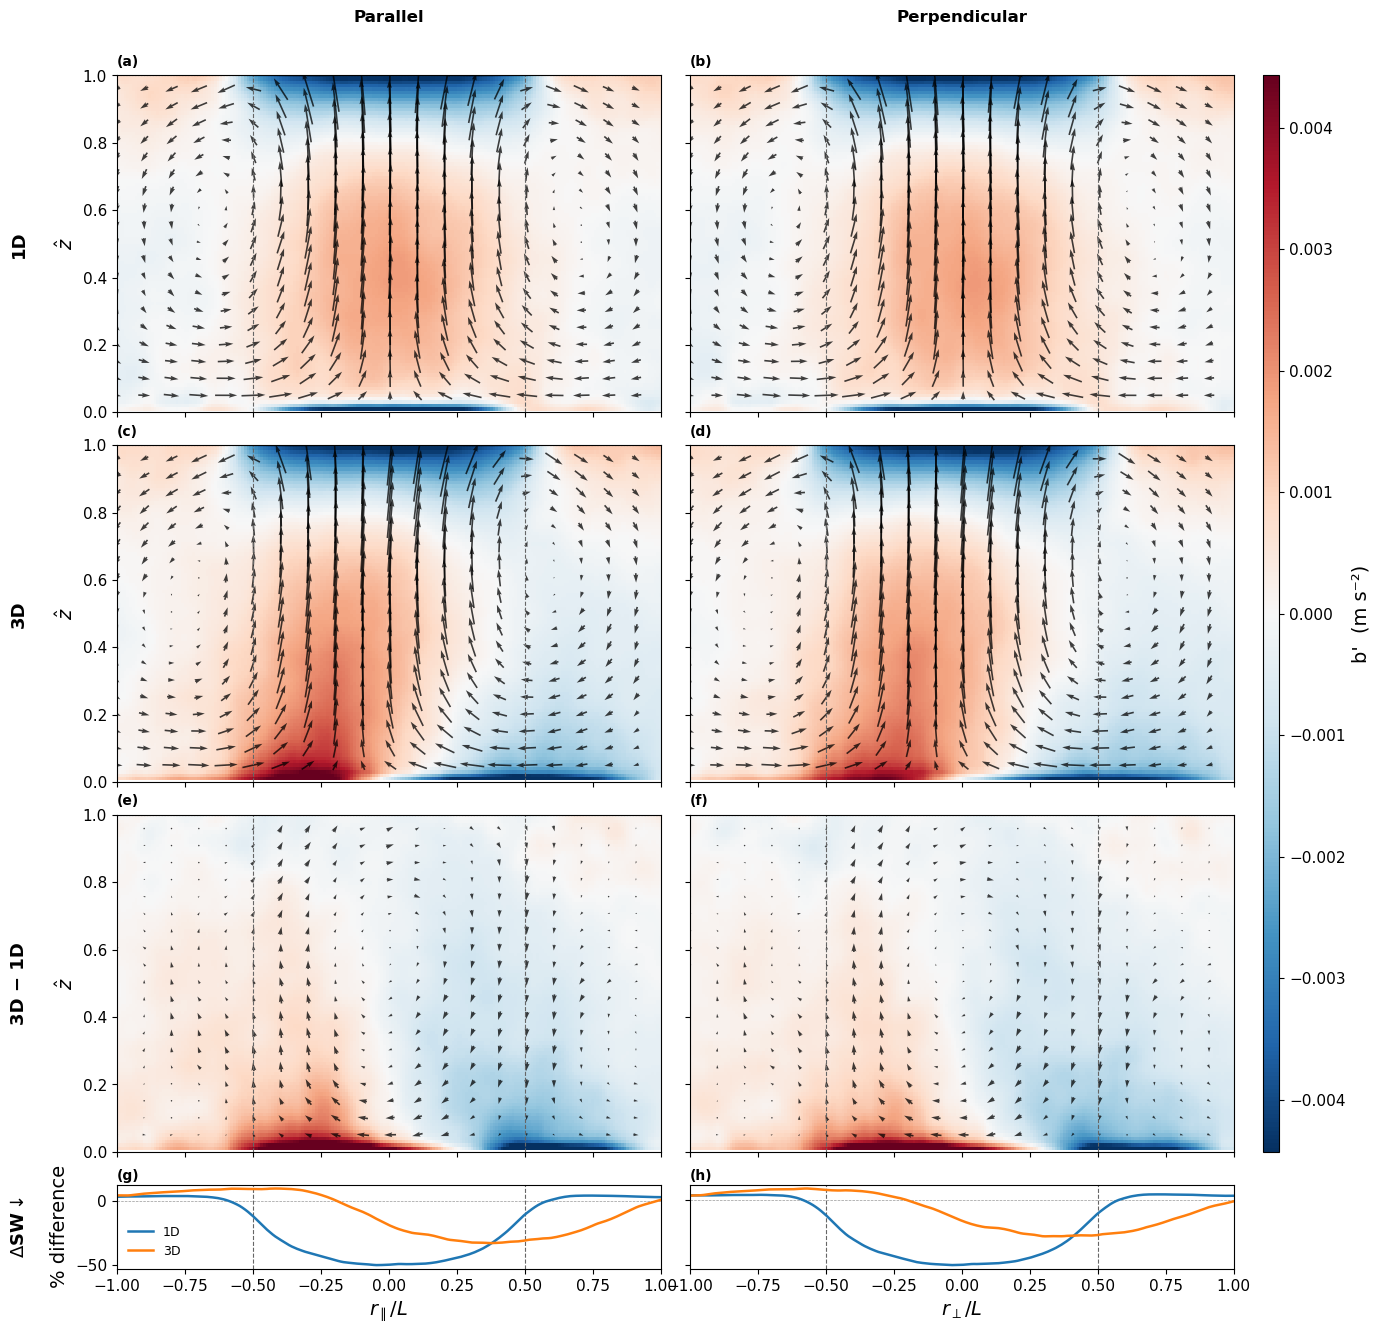


── Window 1: 14:12–15:37  (θ_z 33–50°) ──
   azimuth φ = 258° ± 8°
   1D parallel     : n_events = 144
   3D parallel     : n_events = 134
   1D perpendicular: n_events = 144
   3D perpendicular: n_events = 134


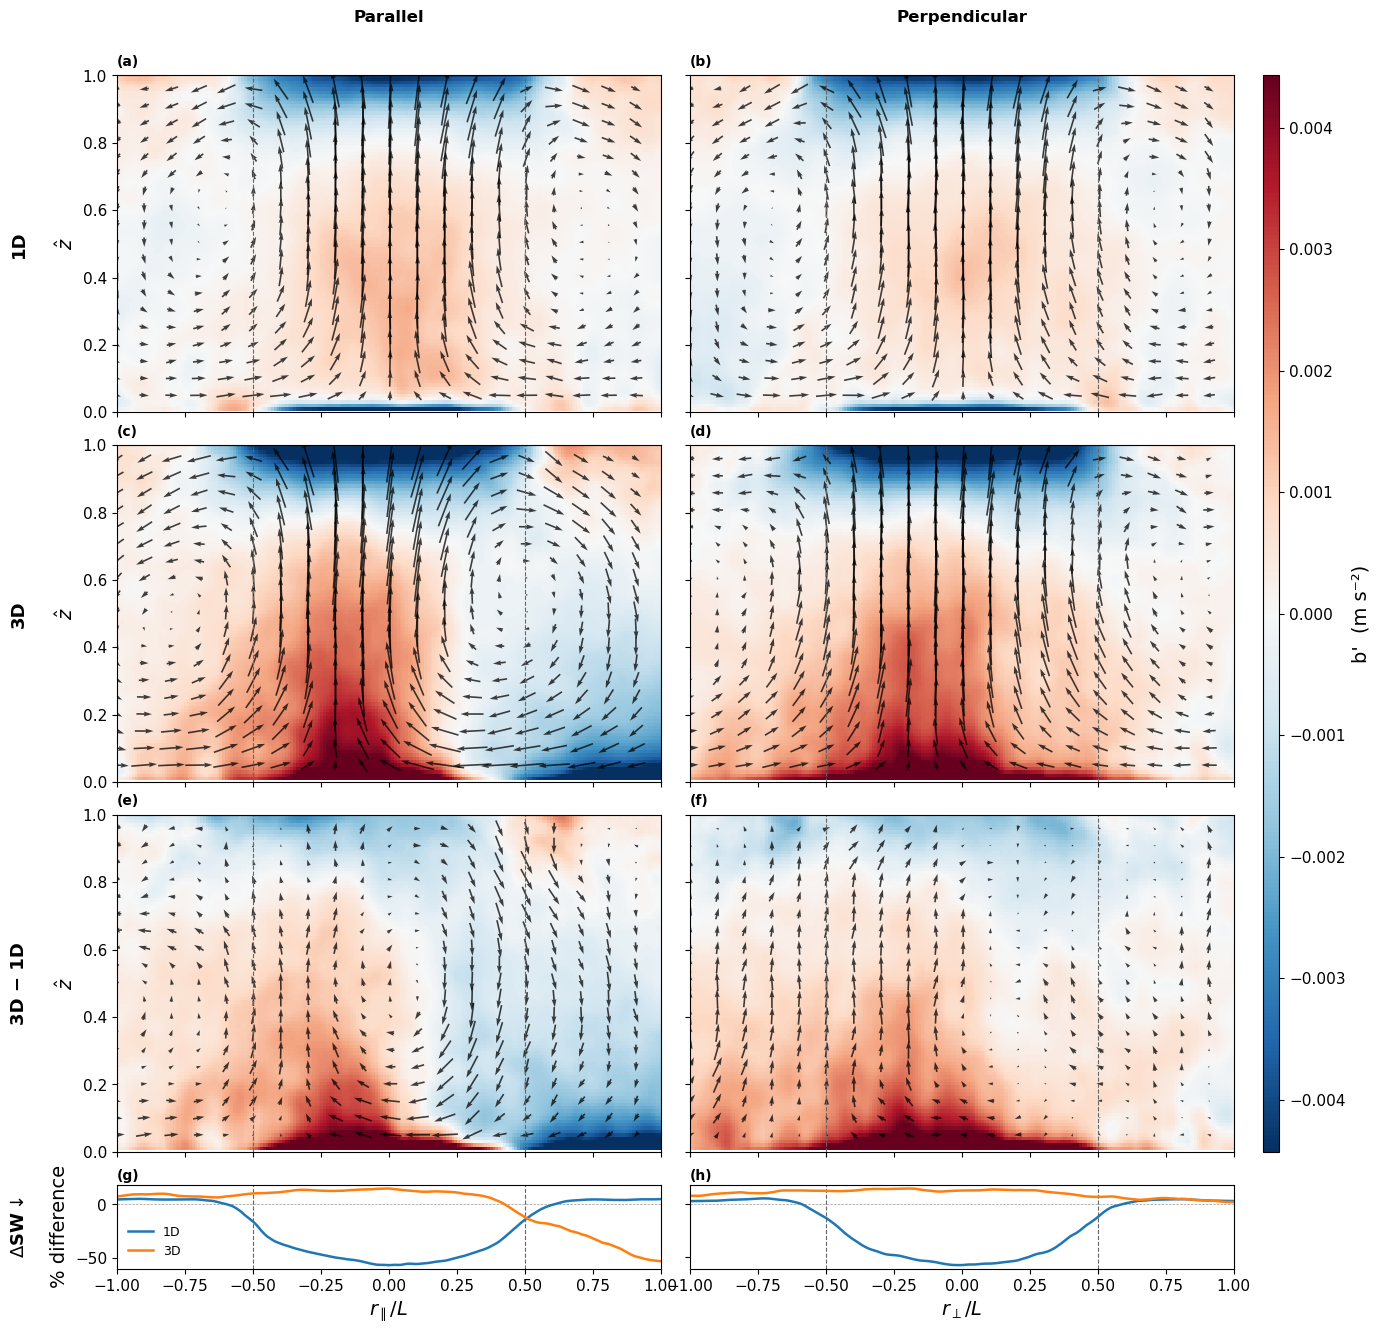


── Window 2: 15:37–17:00  (θ_z 50–67°) ──
   azimuth φ = 272° ± 6°
   1D parallel     : n_events = 141
   3D parallel     : n_events = 165
   1D perpendicular: n_events = 141
   3D perpendicular: n_events = 165


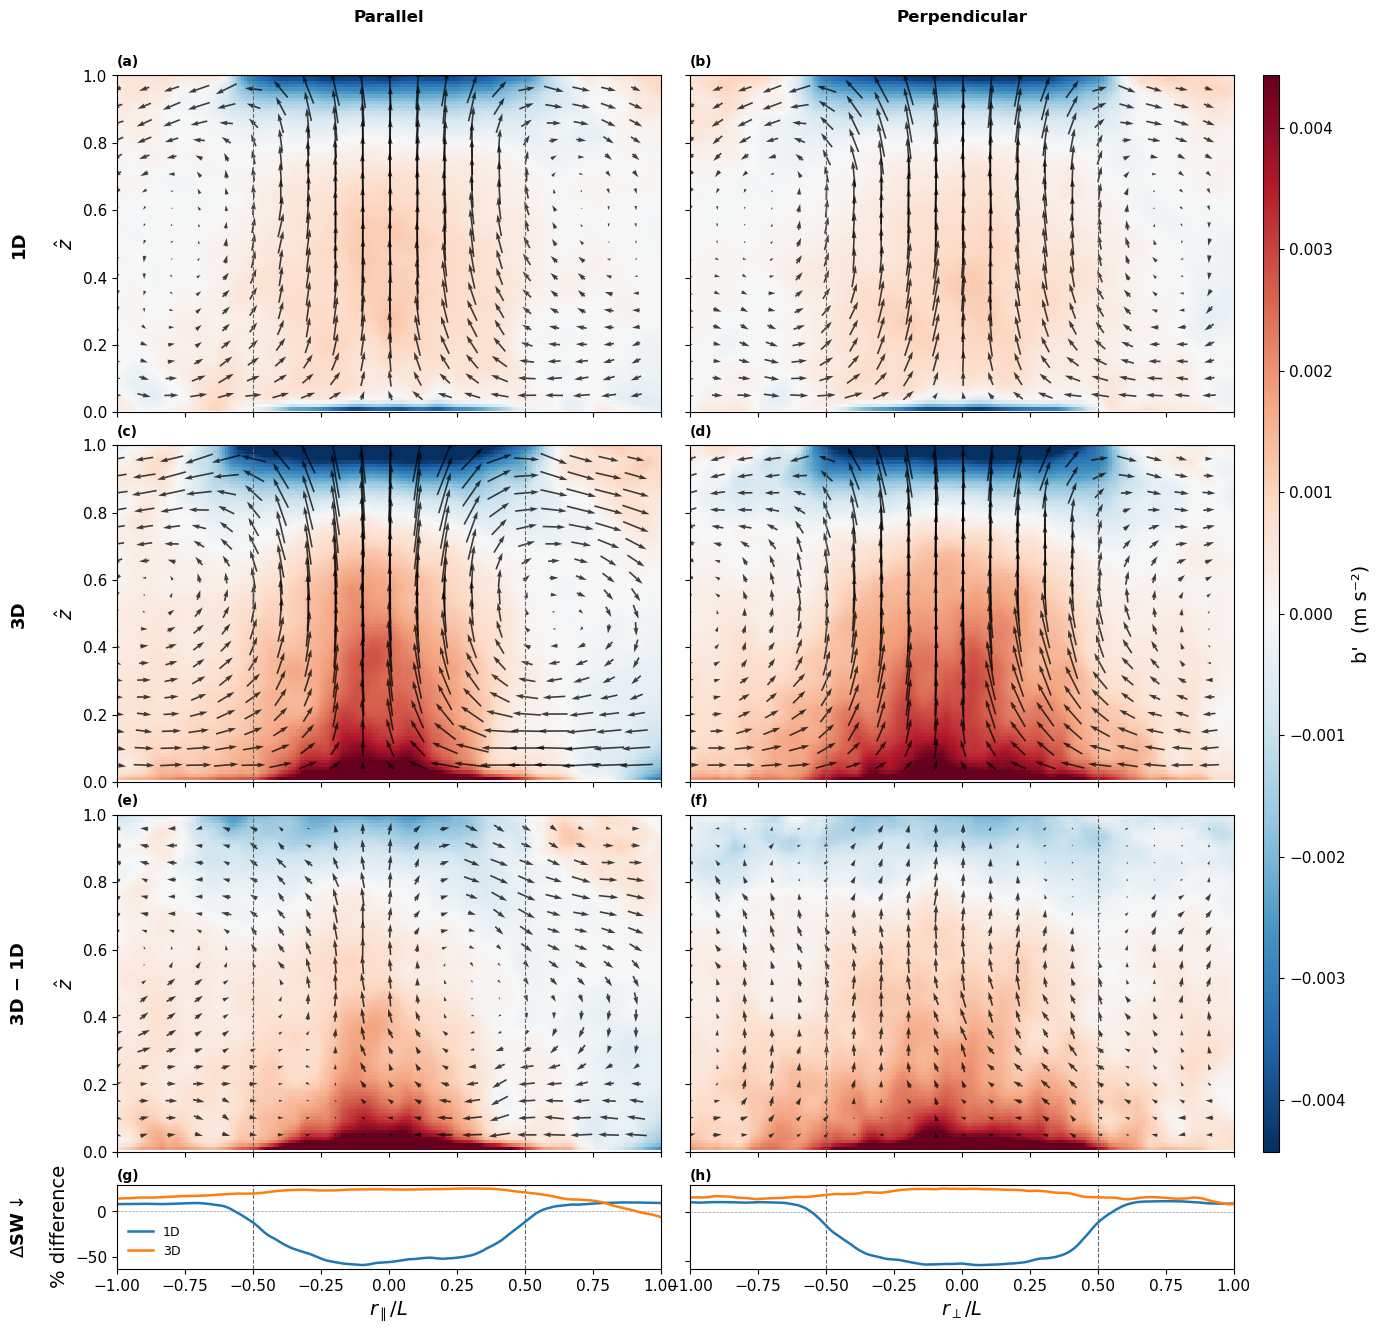

In [34]:
# ── Invoke §3 plot (1D / 3D / diff + SW%, one figure per SZA window) ──────
_vlim_b, _qscale = _compute_global_limits_az(comp_az_data)
_plot_shadow_figure_azimuth(comp_az_data, vlim_b=_vlim_b, shared_qscale=_qscale)


clear-sky reference (1D p98) = 740.8 W m^-2


/tmp/ipykernel_1624265/3570095157.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 1, 0.95])


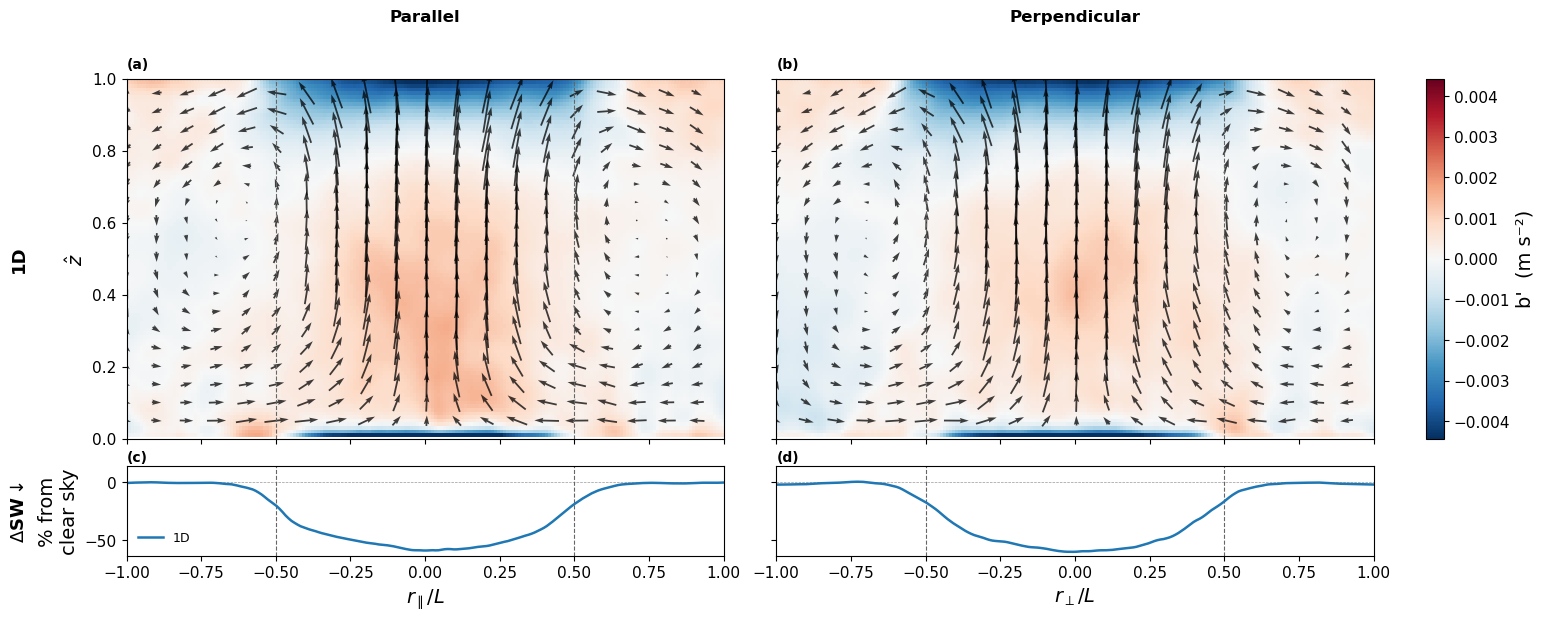

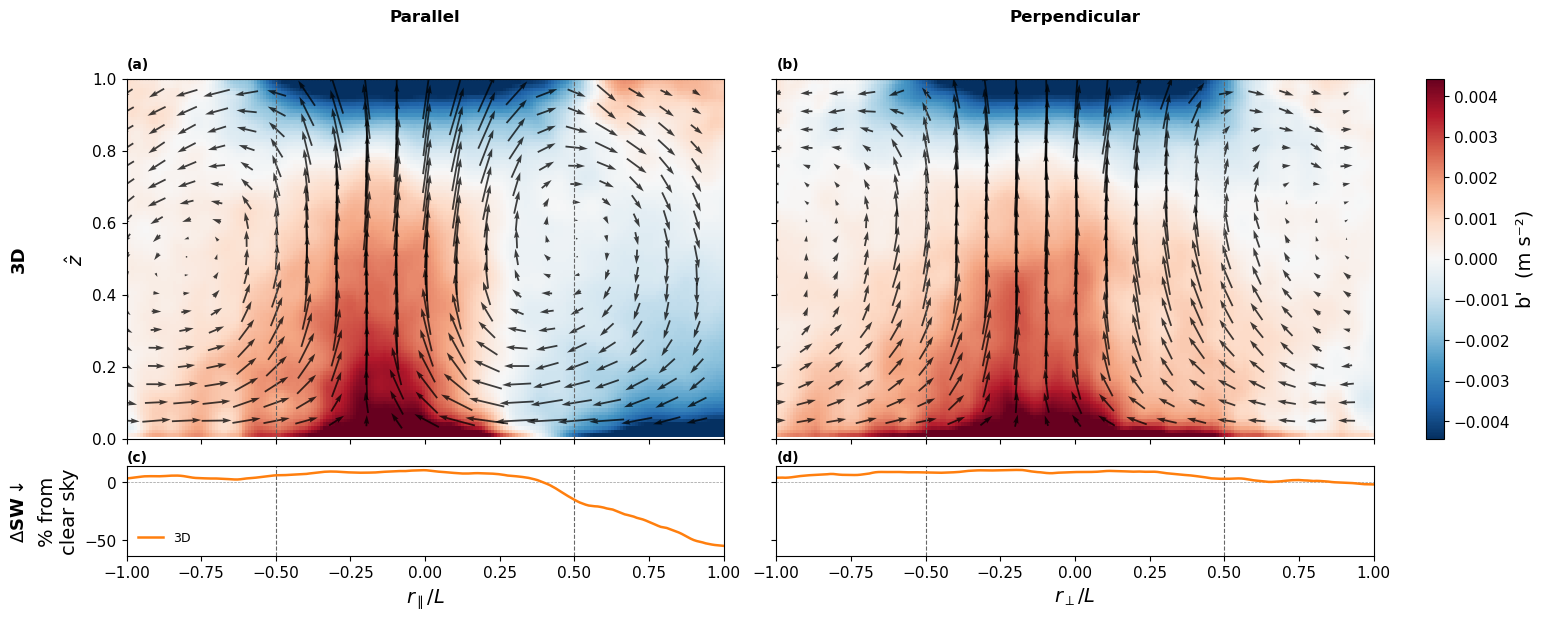

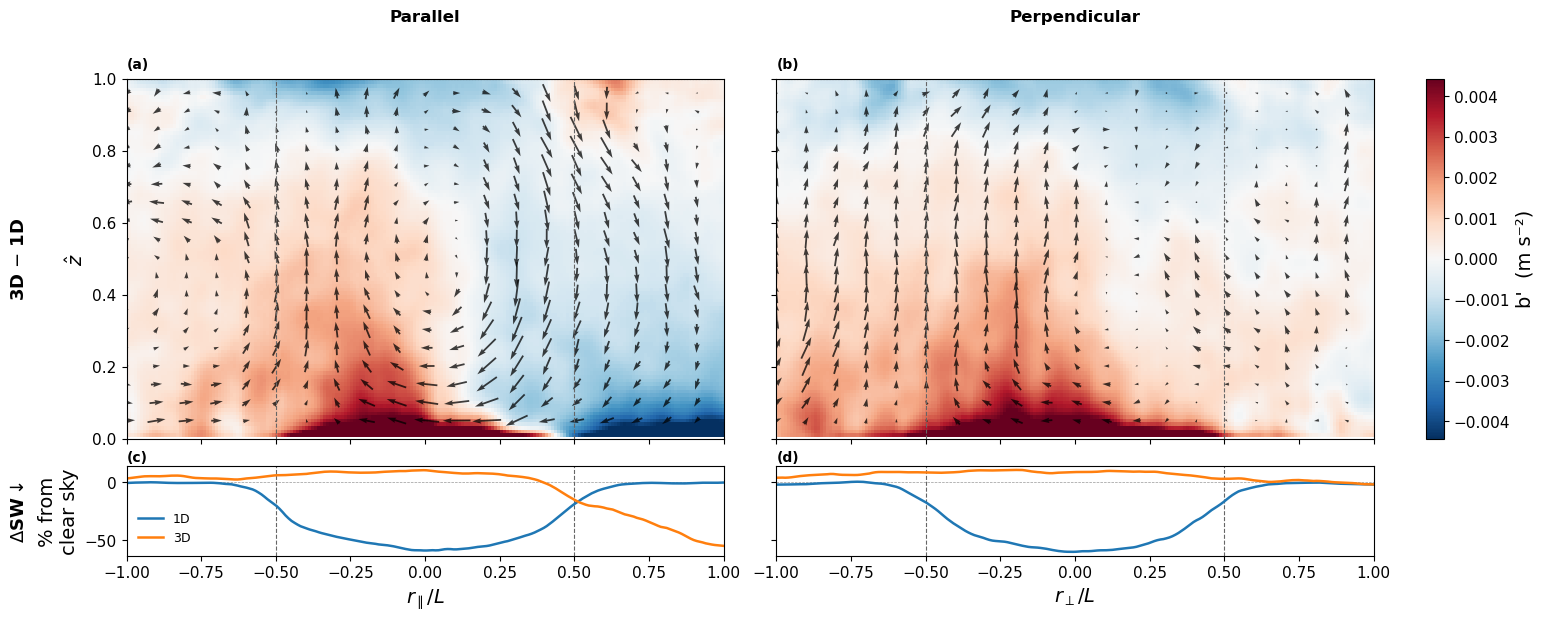

In [50]:
# ── §3 build-up: 3 cropped figs (1D, 3D, diff); ΔSW = % from clear sky ────────
from string import ascii_lowercase

WI       = 1     # window index to present (e.g. 14:12–15:37 band)
CLR_PCT  = 98    # percentile of 1D composite SW used as clear-sky reference


def _clear_sky_ref(comp_az_data, wi, pct=CLR_PCT):
    """Clear-sky surface SW proxy = high percentile of the 1D composite (both dirs)."""
    az = (comp_az_data.get('1D', {}).get(wi, {}) or
          comp_az_data.get('3D', {}).get(wi, {})).get('azimuth_stats')
    if az is None:
        return None
    sp, cp = np.sin(np.radians(az['mean'])), np.cos(np.radians(az['mean']))
    sd = sw_data.get('1D', {})
    vals = []
    for direction in ('parallel', 'perpendicular'):
        Qb = _blend_sw(sd, sp, cp, direction)
        if Qb is not None and wi < Qb.shape[0]:
            Qw = Qb[wi][np.isfinite(Qb[wi])]
            if Qw.size:
                vals.append(Qw)
    return float(np.nanpercentile(np.concatenate(vals), pct)) if vals else None


def _sw_pct(sd, wi, direction, sp, cp, q_clr):
    """% difference of composite SW from the clear-sky reference."""
    Qb = _blend_sw(sd, sp, cp, direction)
    if Qb is None or wi >= Qb.shape[0] or not q_clr:
        return None
    Qw = Qb[wi]
    if np.all(np.isnan(Qw)):
        return None
    return 100.0 * (Qw - q_clr) / q_clr


def _sw_pct_range(comp_az_data, wi, q_clr):
    az = (comp_az_data.get('1D', {}).get(wi, {}) or
          comp_az_data.get('3D', {}).get(wi, {})).get('azimuth_stats')
    if az is None:
        return None
    sp, cp = np.sin(np.radians(az['mean'])), np.cos(np.radians(az['mean']))
    vals = []
    for key in ('1D', '3D'):
        sd = sw_data.get(key, {})
        for direction in ('parallel', 'perpendicular'):
            p = _sw_pct(sd, wi, direction, sp, cp, q_clr)
            if p is not None:
                vals.append(p[np.isfinite(p)])
    if not vals:
        return None
    a = np.concatenate(vals)
    lo, hi = float(np.nanmin(a)), float(np.nanmax(a)); pad = 0.05 * (hi - lo)
    return (lo - pad, hi + pad)


def _plot_shadow_crop(comp_az_data, wi, mode, vlim_b, shared_qscale,
                      q_clr=None, sw_ylim=None):
    """One circulation row (mode='1D'|'3D'|'diff') + matching ΔSW% (from clear sky) row."""
    AXLABEL_FS, TICK_FS = 14, 11
    d1 = comp_az_data.get('1D', {}).get(wi, {})
    d3 = comp_az_data.get('3D', {}).get(wi, {})
    az_stats = (d1 or d3).get('azimuth_stats')

    row_label = {'1D': '1D', '3D': '3D', 'diff': '3D $-$ 1D'}[mode]
    sw_keys   = {'1D': ['1D'], '3D': ['3D'], 'diff': ['1D', '3D']}[mode]

    fig = plt.figure(figsize=(17, 6.2))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.03],
                          height_ratios=[4, 1], hspace=0.12, wspace=0.13)

    pcm_last = None
    row_axes_par = []
    for col_idx, direction in enumerate(['parallel', 'perpendicular']):
        ax_circ = fig.add_subplot(gs[0, col_idx])
        ax_sw   = fig.add_subplot(gs[1, col_idx], sharex=ax_circ)
        ax_circ.tick_params(labelbottom=False)

        # ── circulation panel ──
        if mode == 'diff':
            ds_3d = d3.get(direction); ds_1d = d1.get(direction)
            pcm = _plot_diff_circulation(ax_circ, ds_3d, ds_1d, vlim_b=vlim_b,
                                         orient='xz', show_xlabel=False,
                                         quiver_scale=shared_qscale)
        else:
            ds = (d3 if mode == '3D' else d1).get(direction)
            pcm = plot_circulation_composite(ax_circ, ds, vlim_b=vlim_b,
                                             label='', show_xlabel=False, orient='xz',
                                             show_colorbar=False, quiver_scale=shared_qscale)
            ax_circ.set_title('')
        if pcm is not None:
            pcm_last = pcm

        ax_circ.set_ylabel(r'$\hat{z}$' if col_idx == 0 else '', fontsize=AXLABEL_FS)
        ax_circ.set_xlim(-1, 1); ax_circ.set_ylim(0, 1.0)
        ax_circ.tick_params(labelsize=TICK_FS)
        if col_idx == 1:
            ax_circ.tick_params(labelleft=False)

        # ── ΔSW% (from clear sky) panel ──
        ax_sw.axhline(0, color='0.6', lw=0.5, ls='--')
        ax_sw.axvline(-0.5, color='0.4', lw=0.8, ls='--')
        ax_sw.axvline( 0.5, color='0.4', lw=0.8, ls='--')
        if az_stats is not None:
            sp = np.sin(np.radians(az_stats['mean']))
            cp = np.cos(np.radians(az_stats['mean']))
            for key in sw_keys:
                Q_pct = _sw_pct(sw_data.get(key, {}), wi, direction, sp, cp, q_clr)
                if Q_pct is not None:
                    color = RT_STYLE['2stream']['color'] if key == '1D' else RT_STYLE['raytracer']['color']
                    ax_sw.plot(XL_GRID, Q_pct, color=color, lw=1.8, label=key)

        hl = r'$r_\parallel / L$' if direction == 'parallel' else r'$r_\perp / L$'
        ax_sw.set_ylabel('% from\nclear sky' if col_idx == 0 else '', fontsize=AXLABEL_FS)
        ax_sw.set_xlim(-1, 1); ax_sw.set_xlabel(hl, fontsize=AXLABEL_FS)
        if sw_ylim is not None:
            ax_sw.set_ylim(sw_ylim)
        ax_sw.tick_params(labelsize=TICK_FS)
        if col_idx == 0:
            ax_sw.legend(fontsize=9, frameon=False, loc='lower left')
        else:
            ax_sw.tick_params(labelleft=False)

        ax_circ.text(0.5, 1.15, direction.capitalize(), transform=ax_circ.transAxes,
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

        col_axes = [ax_circ, ax_sw]
        for r_idx, ax in enumerate(col_axes):
            idx = r_idx * 2 + col_idx
            ax.text(0.0, 1.02, f'({ascii_lowercase[idx]})', transform=ax.transAxes,
                    ha='left', va='bottom', fontsize=10, fontweight='bold')
        if col_idx == 0:
            row_axes_par = col_axes

    # rotated side labels
    for ax, lbl in zip(row_axes_par, [row_label, r'$\Delta$SW$\downarrow$']):
        ax.annotate(lbl, xy=(-0.18, 0.5), xycoords='axes fraction',
                    fontsize=13, fontweight='bold', ha='center', va='center', rotation=90)

    # shared colorbar (circ row only)
    if pcm_last is not None:
        cbar_ax = fig.add_subplot(gs[0, 2])
        cb = fig.colorbar(pcm_last, cax=cbar_ax, label="b'  (m s⁻²)")
        cb.ax.yaxis.label.set_size(AXLABEL_FS); cb.ax.tick_params(labelsize=TICK_FS)

    # fig.suptitle(SZA_LABELS[wi], fontsize=12, y=0.98)
    plt.tight_layout(rect=[0.03, 0, 1, 0.95])
    if SAVE_PDF:
        plt.savefig(f'shadow_az_win{wi}_{mode}.pdf', bbox_inches='tight')
    plt.show()


_vlim_b, _qscale = _compute_global_limits_az(comp_az_data)
_q_clr  = _clear_sky_ref(comp_az_data, WI)
_sw_ylim = _sw_pct_range(comp_az_data, WI, _q_clr)
print(f'clear-sky reference (1D p{CLR_PCT}) = {_q_clr:.1f} W m^-2')
for _mode in ('1D', '3D', 'diff'):
    _plot_shadow_crop(comp_az_data, WI, _mode, vlim_b=_vlim_b, shared_qscale=_qscale,
                      q_clr=_q_clr, sw_ylim=_sw_ylim)
